In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
import numpy as np
import ast
import pandas as pd

In [2]:
def plot_cheby_extrapolation(groupbys, df, show_stdevs):
    for group_name, group in df.groupby(groupbys):
        print(f"Group: {group_name}")
        exact_eigenvalue = (group["exact_eig"].iloc[0])
        print(f"Exact Eigenvalue: {exact_eigenvalue}")
        alpha = group["alpha"].iloc[0]
        print(f"Alpha: {alpha}")
        num_ancilla = group["num_ancilla"].iloc[0]
        print(f"Num Ancilla: {num_ancilla}")
        num_qdrift_segments = group["num segments per invocation"].iloc[0] if "num segments per invocation" in group.columns else 1

        # mirror the results across the y-axis to duplicte the data (phyics math moment)
        df_mirror = group.copy()
        df_mirror["time"] = -df_mirror["time"]
        group = pd.concat([group, df_mirror])

        # Calculate theoretical upper bound for standard deviation
        stdev_theoretical_upper_bound = (alpha ** 2 * group["time"] ** 2) / num_qdrift_segments

        # if show_stdevs is True, plot two subplots, one for the estimated eigenvalue and one for the standard deviation
        if show_stdevs:
            fig, axs = plt.subplots(1, 2, figsize=(15, 5))
            ax1, ax2 = axs
        else:
            fig, ax1 = plt.subplots(figsize=(10, 6))
            ax2 = None
        ax1.plot(group["time"], group["est_energy_mean"], marker='o', linestyle='None')
        # fit a polynomial to the data
        coeffs = Polynomial.fit(group["time"], group["est_energy_mean"], 2).convert().coef
        print(f"Polynomial Coefficients: {coeffs}")
        y_intercept = coeffs[0]
        print(f"Y-intercept at x = 0: {y_intercept}")
        print(f"Correct eigenvalue: {exact_eigenvalue}")
        best_datapoint = np.argmin(np.abs(group["est_energy_mean"] - exact_eigenvalue))
        print(f"best approximation from chebyshev nodes: {group.iloc[best_datapoint]['est_energy_mean']}")
        if (abs(exact_eigenvalue - y_intercept) < abs(exact_eigenvalue - group.iloc[best_datapoint]['est_energy_mean'])):
            print("Extrapolated value is a better approximation than any of the chebyshev nodes!")
        else:
            print("Extrapolated value is NOT a better approximation than the best chebyshev node.")
        # Extrapolation range (extend 20% beyond the last x)
        x_extra = np.linspace(group["time"].min() * 1.01, group["time"].max() * 1.01, 200)
        y_extra = sum(c * x_extra**i for i, c in enumerate(coeffs))
        ax1.plot(x_extra, y_extra, label='Extrapolated Curve', color='orange')
        ax1.axhline(y=y_intercept, color='g', linestyle='--',
                    label='Extrapolated Eigenvalue')
        ax1.axhline(y=exact_eigenvalue, color='r', linestyle='--',
                    label='Exact Eigenvalue')   
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Estimated Eigenvalue")
        ax1.set_title(f"Estimated Eigenvalue vs Time (Exact: {exact_eigenvalue})")
        # add textbox info about the extrapolated eigenvalue
        stats_text = (f"Extrapolated Eigenvalue: {y_intercept:.4f}\n"
                        f"Absolute Error: {abs(exact_eigenvalue - y_intercept):.4f}\n"
                        f"Alpha: {alpha:.4f}\n"
                        f"Num Ancilla: {num_ancilla}\n"
                        f"Num Segments: {num_qdrift_segments}\n")
        if "Num Random Circuits" in group.columns:
            num_random_circuits = group["Num Random Circuits"].iloc[0]
            stats_text += f"Num Random Circuits: {num_random_circuits}\n"
        ax1.text(-0.35, 0.95, stats_text, transform=ax1.transAxes,
                 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # plot the theoretical upper bound for standard deviation and real stdev vs time
        if show_stdevs:
            ax2.plot(group["time"], group["est_energy_std"], marker='o', linestyle='None', label='Real Standard Deviation')
            ax2.plot(group["time"], stdev_theoretical_upper_bound, marker='x', linestyle='None', label='Theoretical Upper Bound for qDRIFT channel (ignoring qpe error)')
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel("Standard Deviation")
            ax2.set_title(f"Standard Deviation vs Time (Alpha: {alpha}, Num Ancilla: {num_ancilla})")
            ax2.grid(True)
            ax2.legend()
        ax1.grid(True)
        ax1.legend()
        plt.tight_layout()
        plt.show()




Group: (np.int64(1), np.int64(1))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [3.82039329e-01 3.76376696e-16 4.98451277e+00]
Y-intercept at x = 0: 0.38203932937740226
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8323584993594351
Extrapolated value is NOT a better approximation than the best chebyshev node.


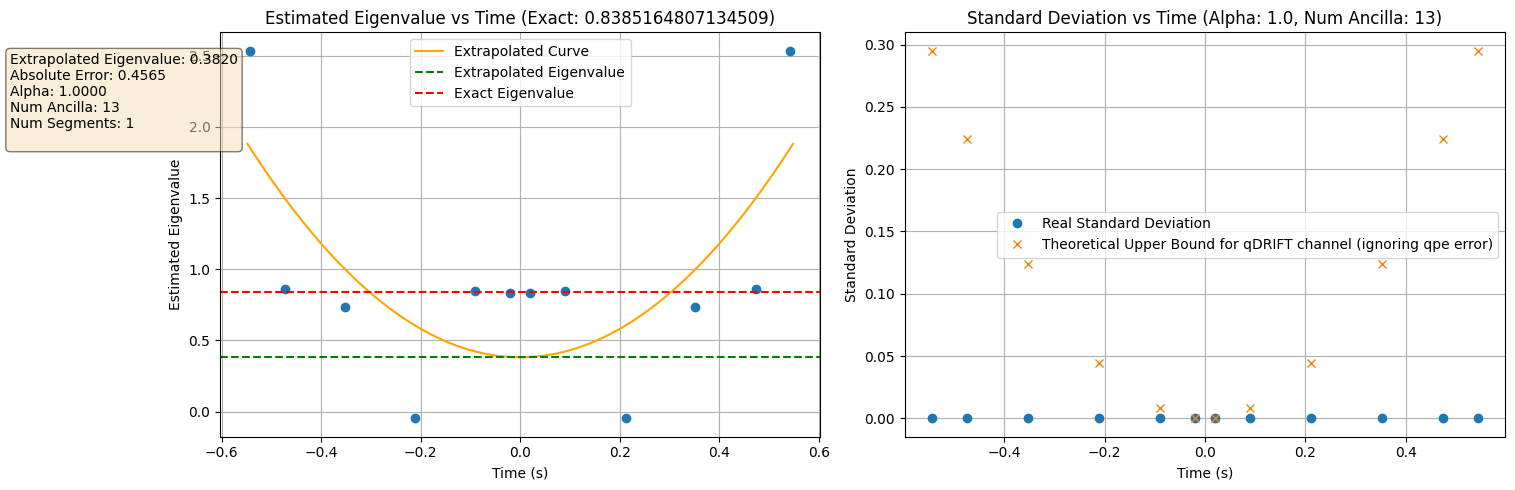

Group: (np.int64(1), np.int64(10))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [7.86320817e-01 1.29379489e-16 1.90080084e-01]
Y-intercept at x = 0: 0.7863208170915735
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8387052100156479
Extrapolated value is NOT a better approximation than the best chebyshev node.


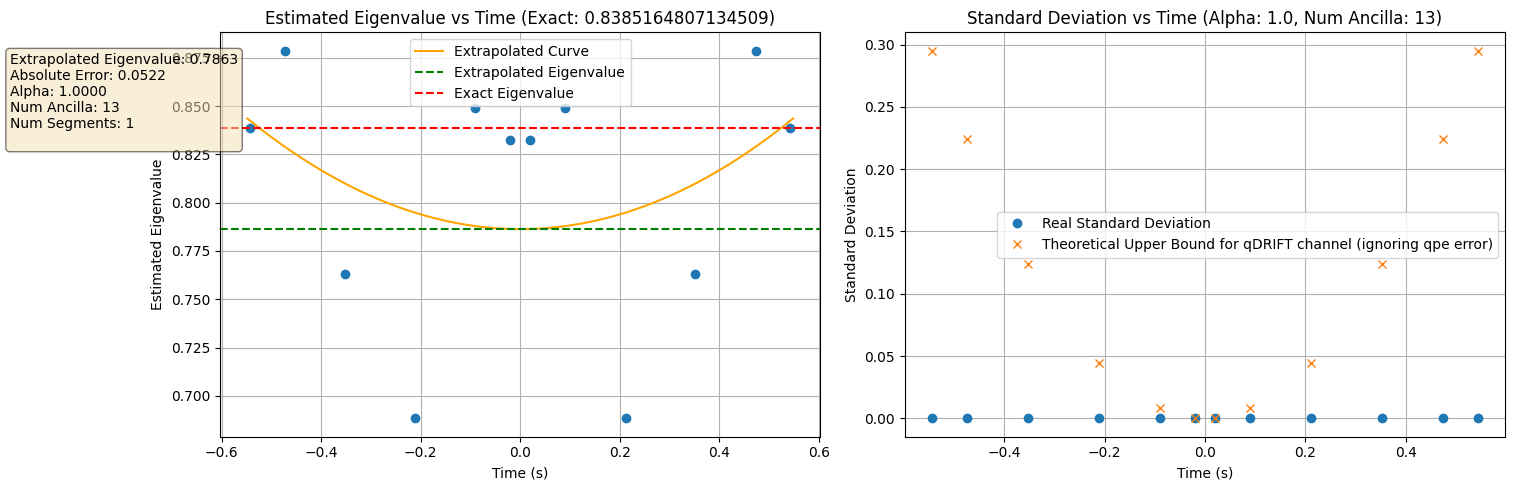

Group: (np.int64(1), np.int64(100))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [8.18005924e-01 1.41141261e-16 1.19345267e-01]
Y-intercept at x = 0: 0.8180059240470946
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8396956535355118
Extrapolated value is NOT a better approximation than the best chebyshev node.


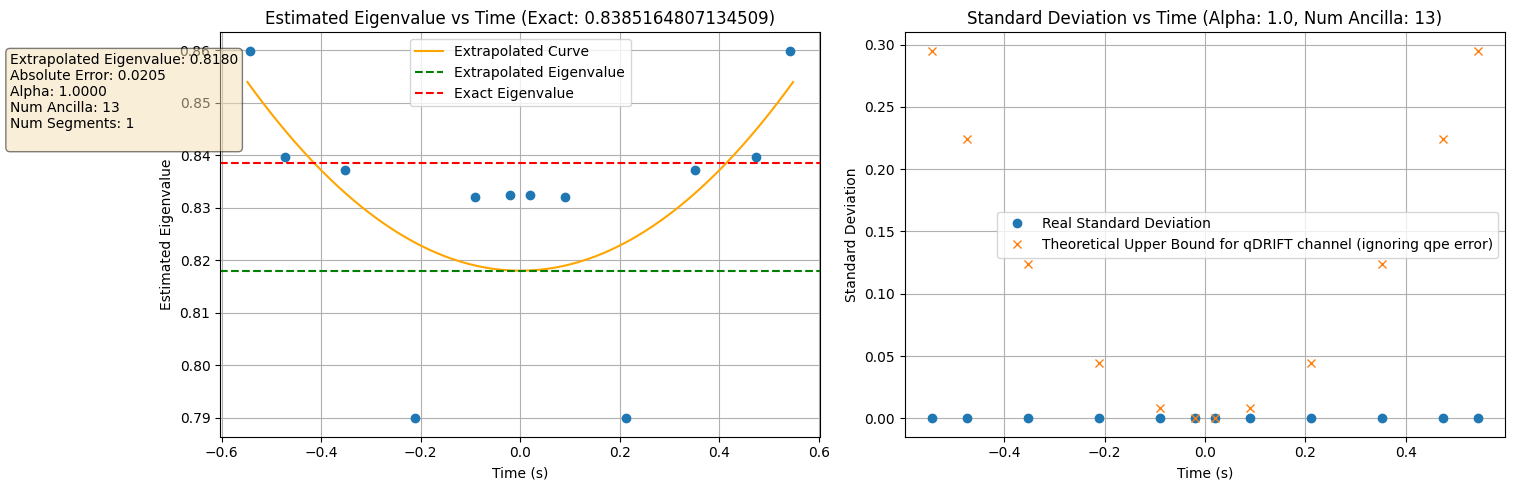

Group: (np.int64(10), np.int64(1))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [ 9.19071721e-01  1.88188348e-16 -9.16168212e-01]
Y-intercept at x = 0: 0.9190717208670605
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8550591857056015
Extrapolated value is NOT a better approximation than the best chebyshev node.


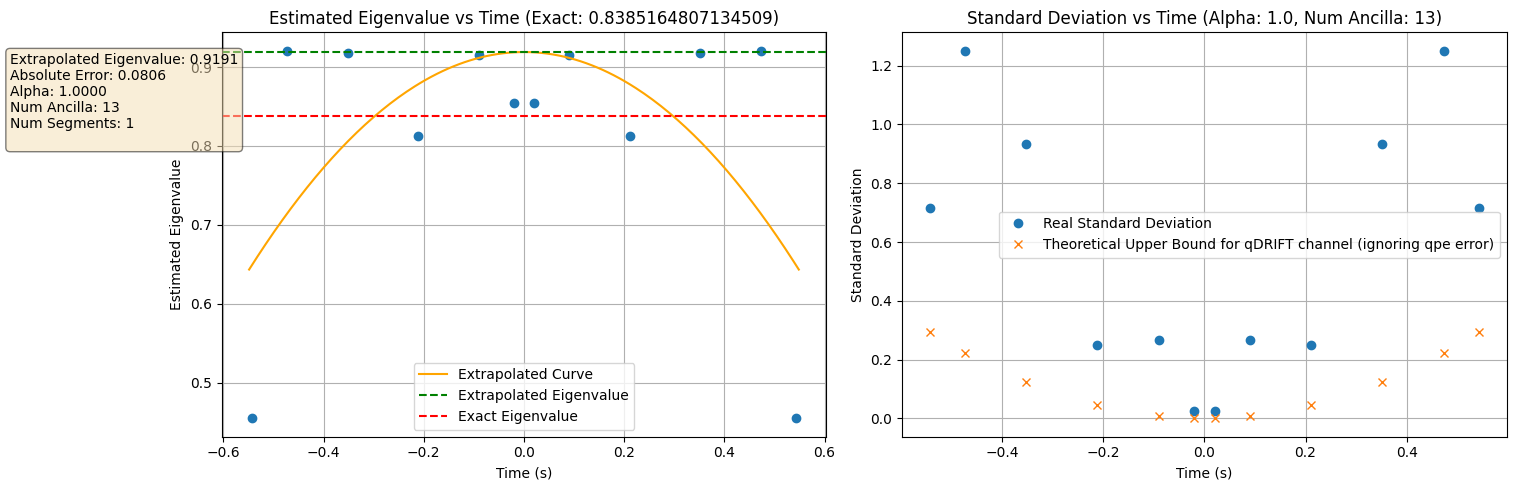

Group: (np.int64(10), np.int64(10))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [8.58561600e-01 4.70470870e-17 5.89162969e-01]
Y-intercept at x = 0: 0.8585616003592125
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8460501579770148
Extrapolated value is NOT a better approximation than the best chebyshev node.


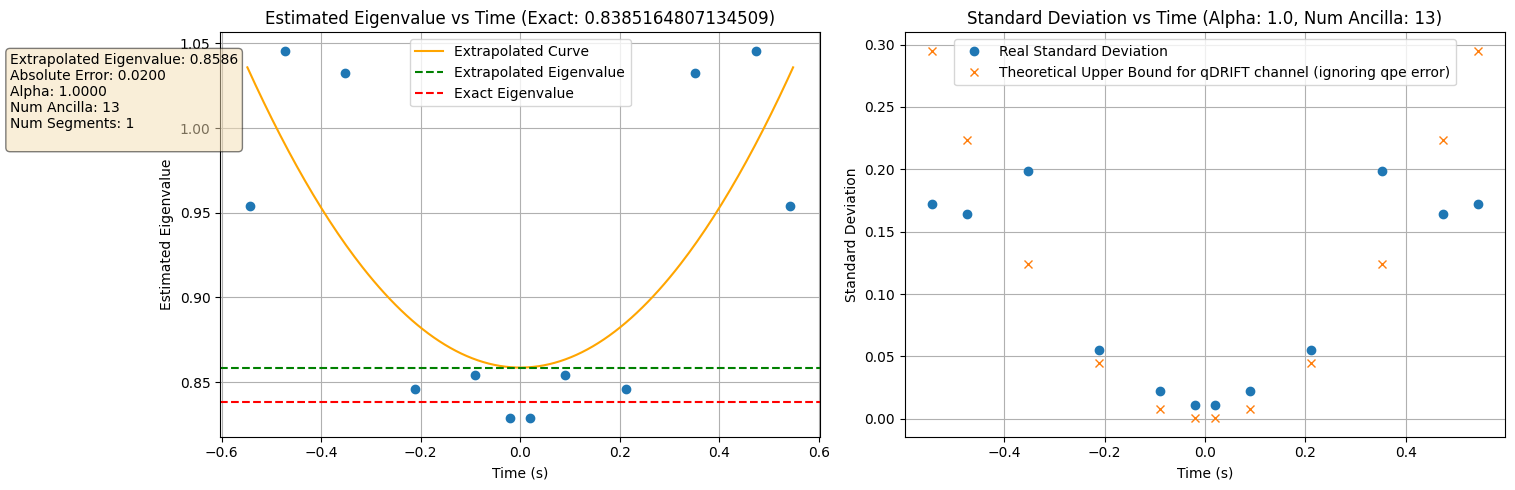

Group: (np.int64(10), np.int64(100))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [8.34037699e-01 2.35235435e-16 4.62185382e-01]
Y-intercept at x = 0: 0.8340376994555665
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8405838361583735
Extrapolated value is NOT a better approximation than the best chebyshev node.


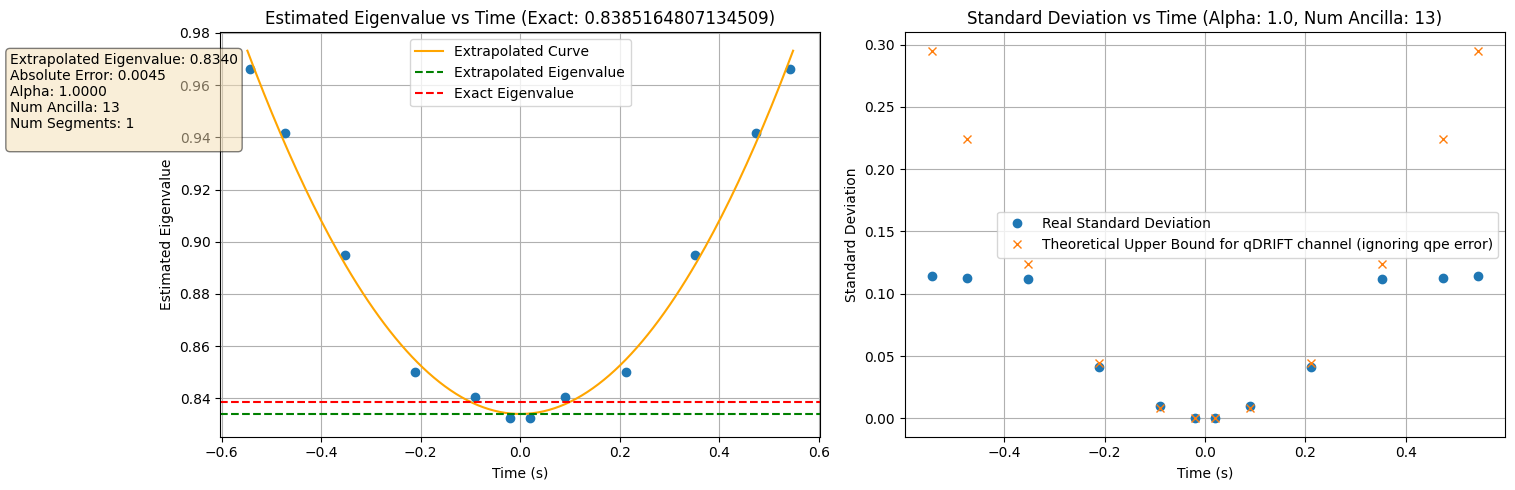

Group: (np.int64(100), np.int64(1))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [6.24082523e-01 1.88188348e-16 1.14191929e+00]
Y-intercept at x = 0: 0.6240825230554843
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8437088425325198
Extrapolated value is NOT a better approximation than the best chebyshev node.


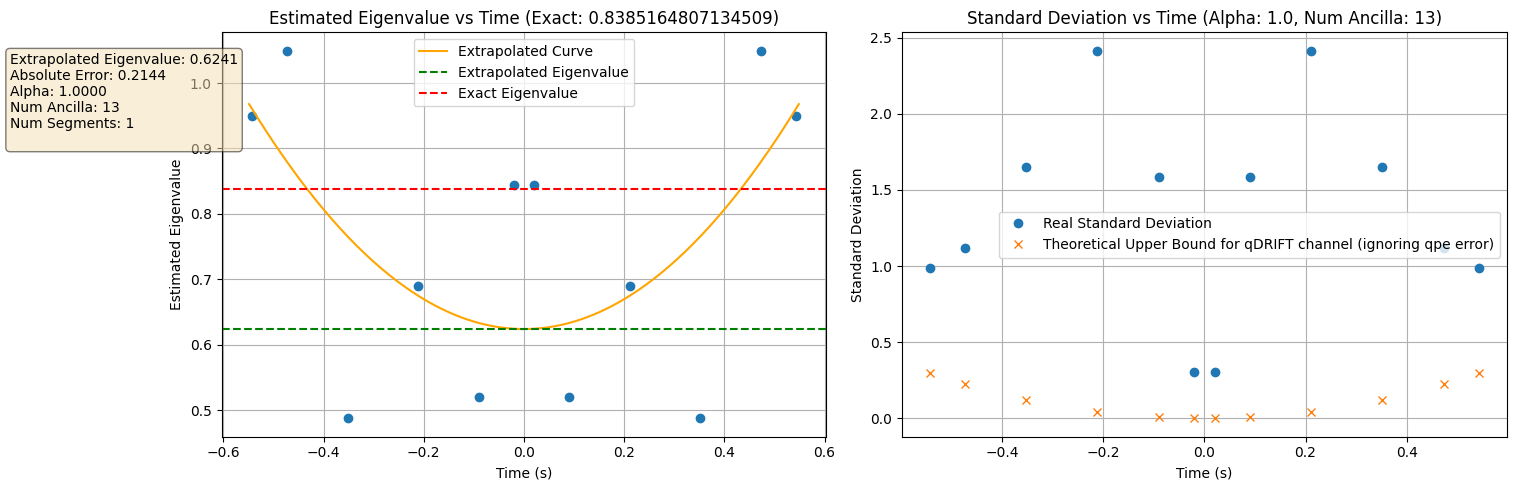

Group: (np.int64(100), np.int64(10))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [8.45787246e-01 2.35235435e-16 7.04779980e-01]
Y-intercept at x = 0: 0.8457872456893067
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8327368441318709
Extrapolated value is NOT a better approximation than the best chebyshev node.


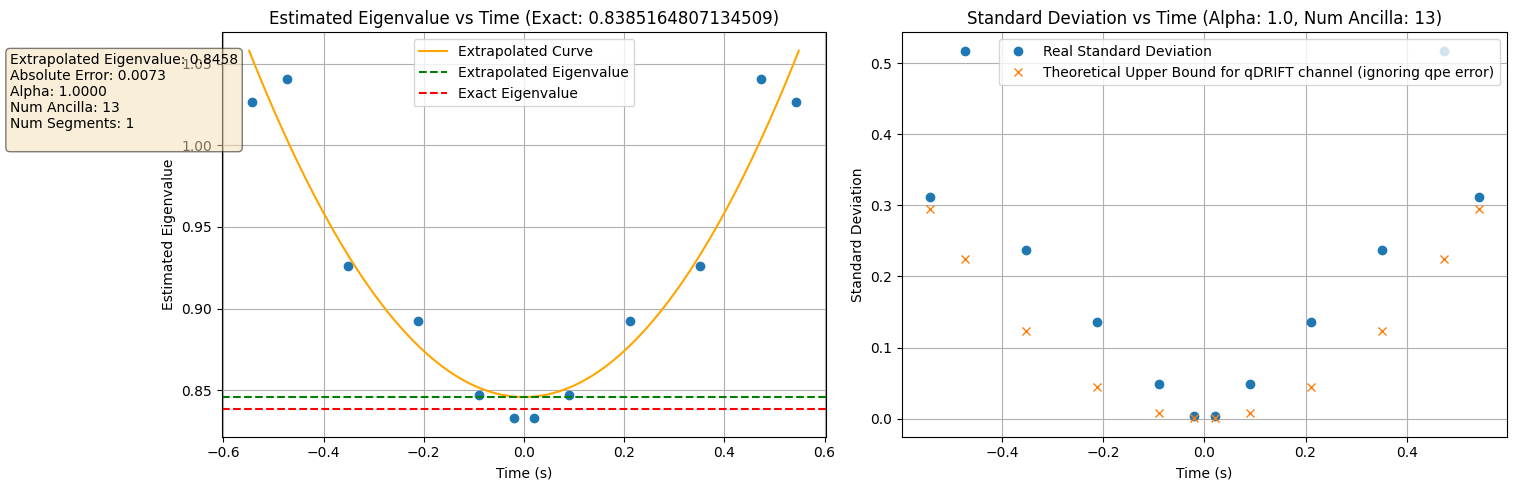

Group: (np.int64(100), np.int64(100))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [8.38781132e-01 1.88188348e-16 5.18595031e-01]
Y-intercept at x = 0: 0.8387811322503115
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.842112170405934
Extrapolated value is a better approximation than any of the chebyshev nodes!


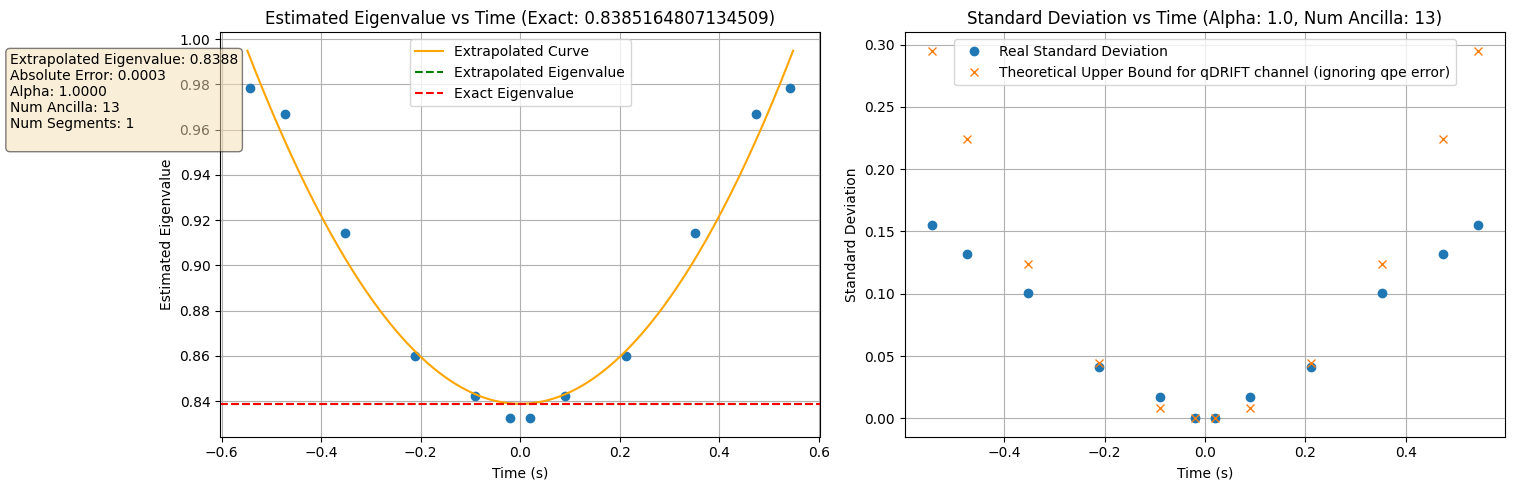

Group: (np.int64(1000), np.int64(1))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [ 8.75757278e-01  1.17617717e-16 -3.76336956e-01]
Y-intercept at x = 0: 0.8757572780167074
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8392178373675703
Extrapolated value is NOT a better approximation than the best chebyshev node.


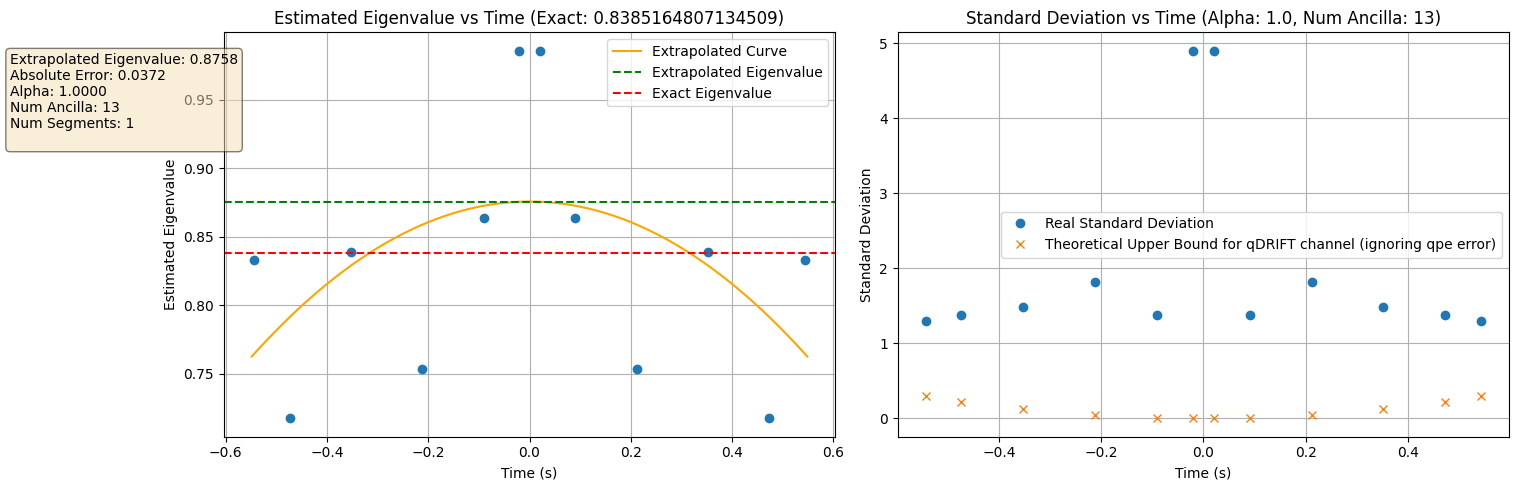

Group: (np.int64(1000), np.int64(10))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [8.57392627e-01 1.88188348e-16 6.38713563e-01]
Y-intercept at x = 0: 0.8573926269208657
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8330016854725711
Extrapolated value is NOT a better approximation than the best chebyshev node.


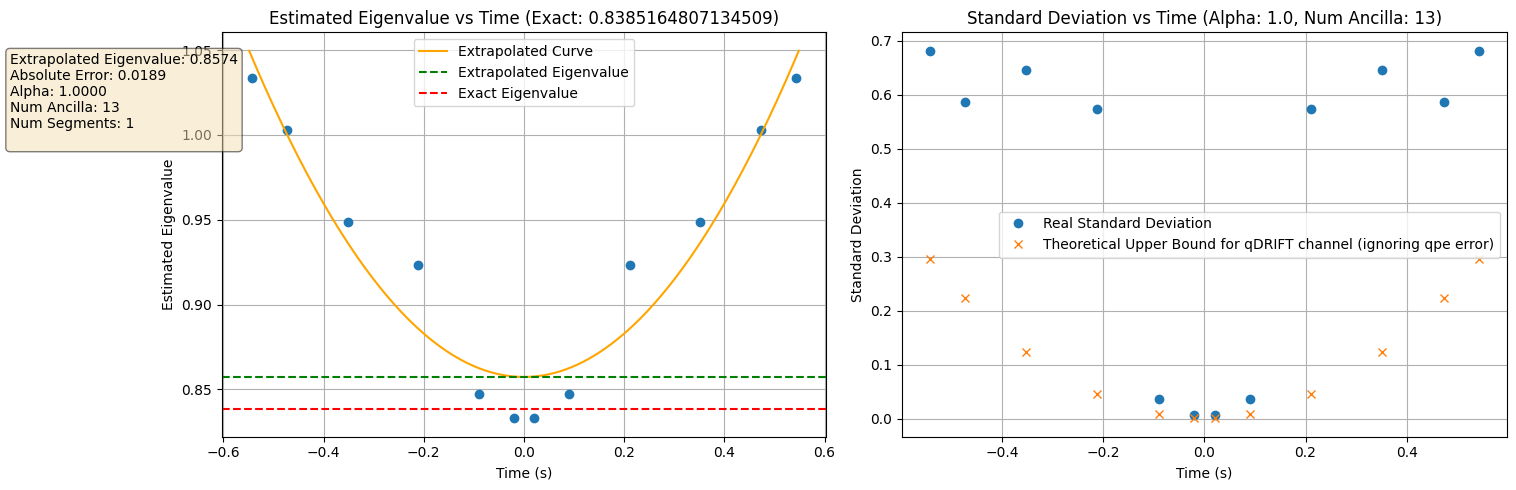

Group: (np.int64(1000), np.int64(100))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 13
Polynomial Coefficients: [ 8.39851314e-01 -4.70470870e-17  4.97064955e-01]
Y-intercept at x = 0: 0.8398513136805893
Correct eigenvalue: 0.8385164807134509
best approximation from chebyshev nodes: 0.8434621989912968
Extrapolated value is a better approximation than any of the chebyshev nodes!


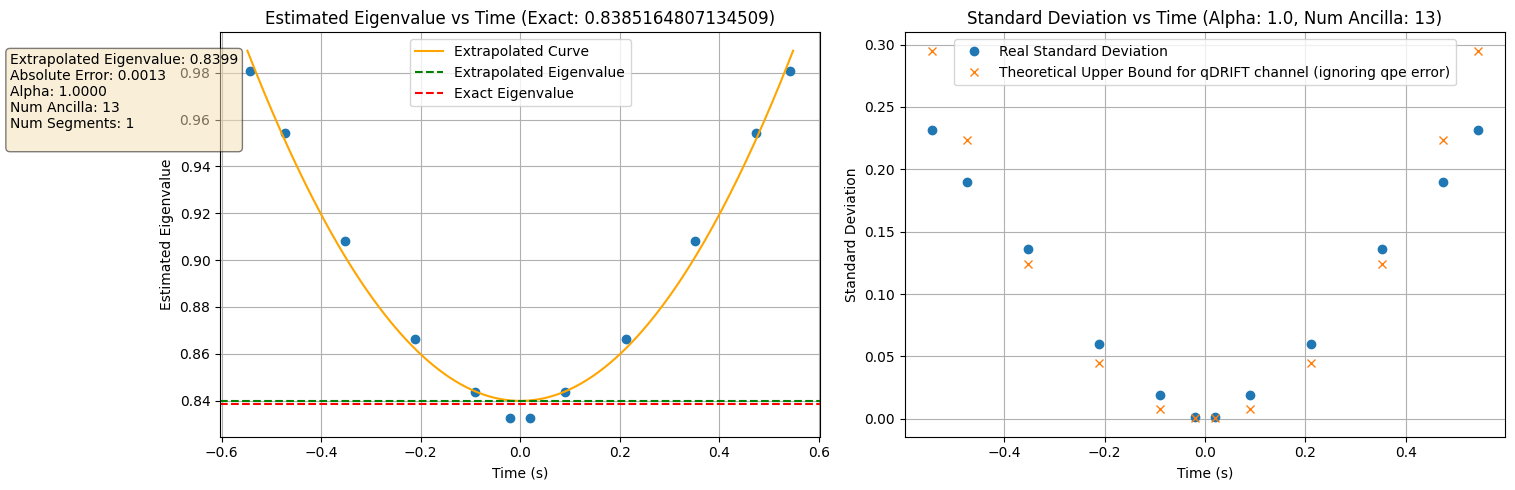

In [3]:
df = pd.read_csv("C:\\Users\\Ro\\Desktop\\qDriftExtraPolation\\qdrift_qpe_fc_parameter_sweep_2025-10-26.csv")
plot_cheby_extrapolation(["n_circuits", "n_shots"], df, show_stdevs=True)

Group: (np.float64(1.0), np.int64(12))
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 12
Polynomial Coefficients: [9.32024062e-01 8.15928298e-17 4.10369687e-02]
Y-intercept at x = 0: 0.9320240621187805
Correct eigenvalue: 0.8385164807134509
Error ratio: 0.11151549618412847


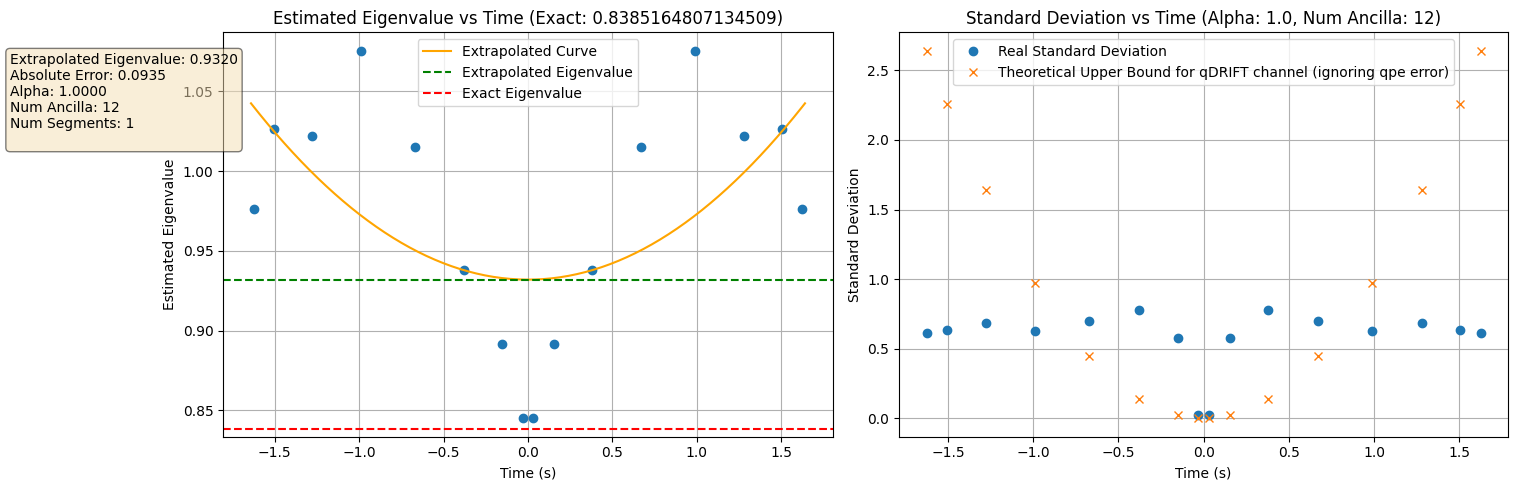

In [7]:
df = pd.read_csv("C:\\Users\\rodcs\\Desktop\\my-repos\\qDriftExtraPolation\\qdrift_qpe_fc_parameter_sweep_2025-10-20.csv")
plot_cheby_extrapolation(["alpha", "num_ancilla"], df, show_stdevs=True)

Group: ('1 qubit test',)
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 12
Polynomial Coefficients: [ 9.60814990e-01 -9.15980009e-17  6.90234825e-02]
Y-intercept at x = 0: 0.9608149896773093
Correct eigenvalue: 0.8385164807134509
Error ratio: 0.1458510497728093


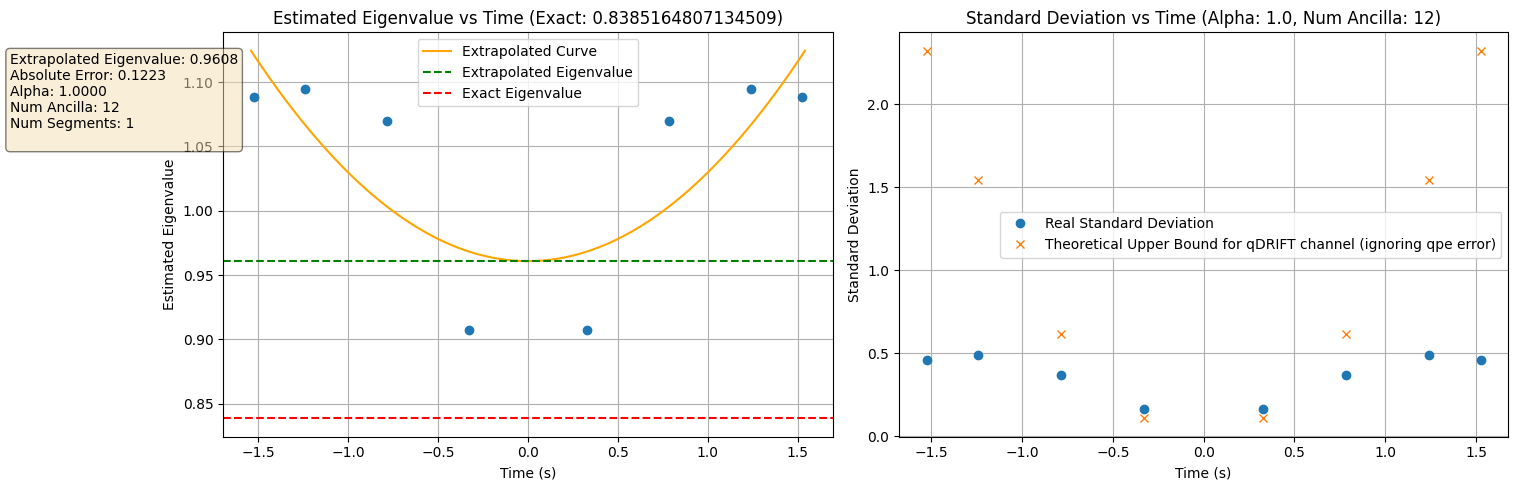

Group: ('diagonal 1 qubit',)
Exact Eigenvalue: 0.7999999999999999
Alpha: 1.2
Num Ancilla: 12
Polynomial Coefficients: [ 1.20046934e+00 -1.01992227e-16 -1.11186260e-04]
Y-intercept at x = 0: 1.200469342188463
Correct eigenvalue: 0.7999999999999999
Error ratio: 0.5005866777355787


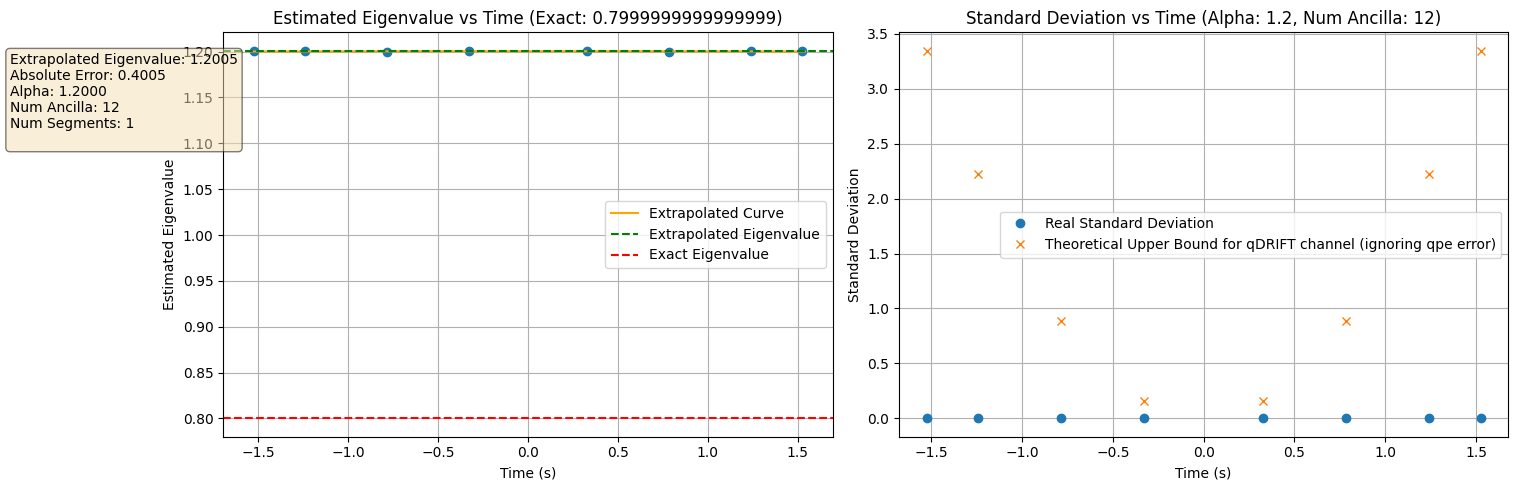

In [10]:
df = pd.read_csv(r"C:\Users\rodcs\Desktop\my-repos\qDriftExtraPolation\qdrift_qpe_fc_parameter_sweep_2025-10-02.csv")
df = df[df["time"] > df["time"].min()]  # filter out the zero time data points
plot_cheby_extrapolation(groupbys=["ham"], df=df, show_stdevs=True)

Group: ('1 qubit test',)
Exact Eigenvalue: 0.8385164807134509
Alpha: 1.0
Num Ancilla: 10
Polynomial Coefficients: [9.66143432e-01 4.57885143e-18 7.99252385e-03]
Y-intercept at x = 0: 0.9661434321547674
Correct eigenvalue: 0.8385164807134509
Error ratio: 0.15220565650984613


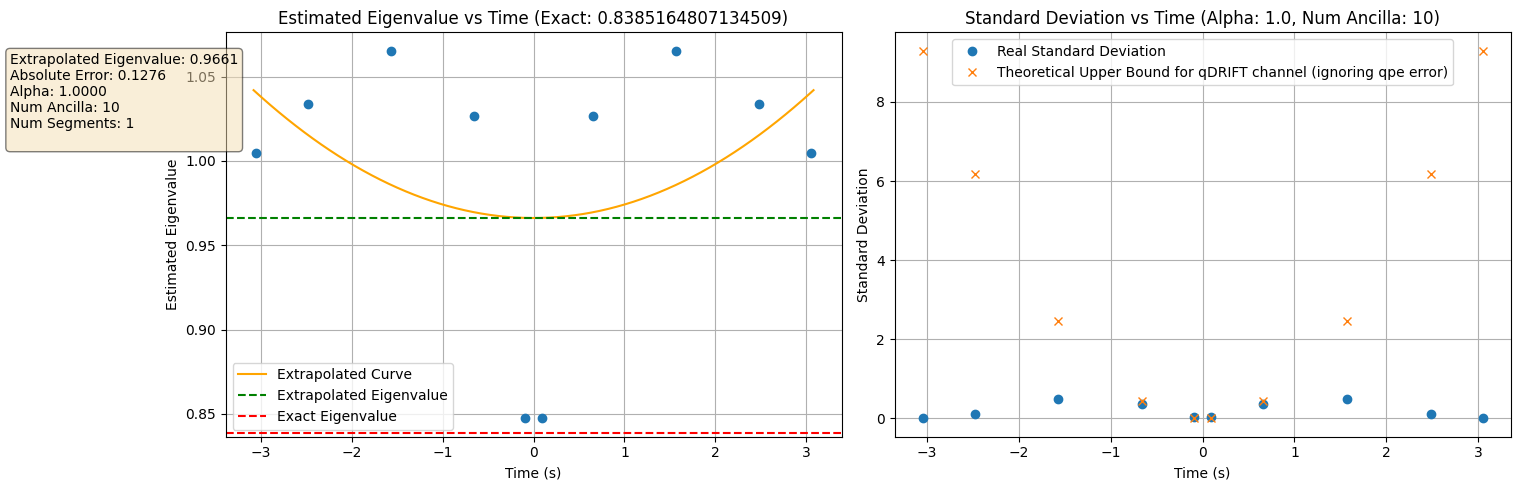

Group: ('diagonal 1 qubit',)
Exact Eigenvalue: 0.7999999999999999
Alpha: 1.2
Num Ancilla: 10
Polynomial Coefficients: [ 1.46111908e+00 -3.52797294e-17 -1.83230291e-01]
Y-intercept at x = 0: 1.461119080479121
Correct eigenvalue: 0.7999999999999999
Error ratio: 0.8263988505989014


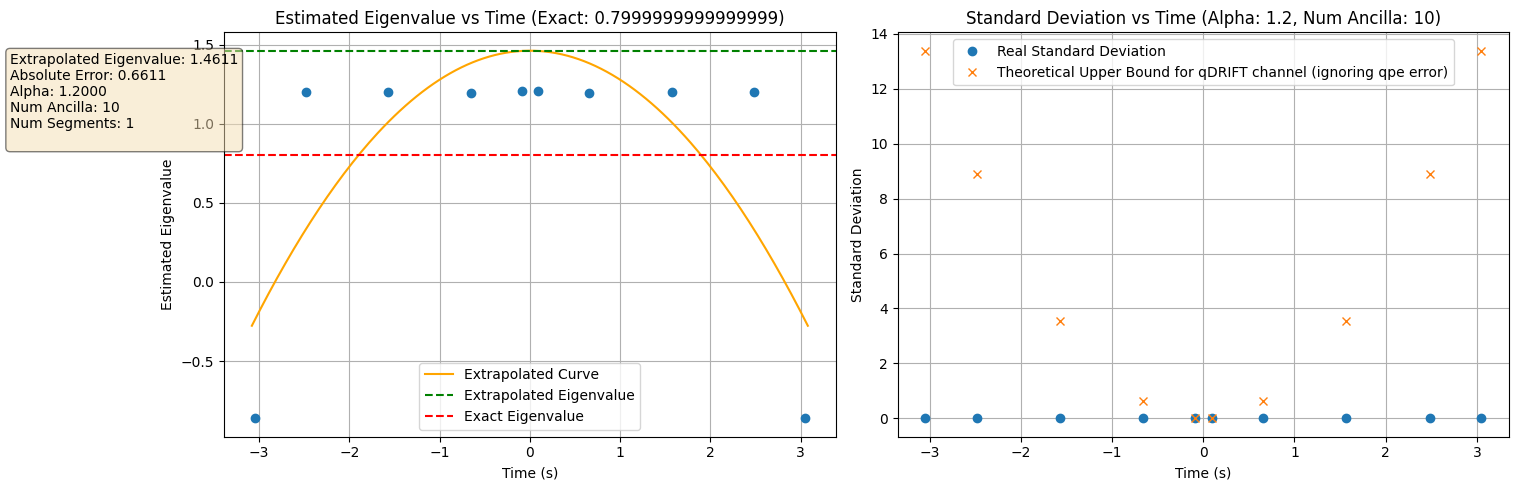

In [8]:
df = pd.read_csv(r"C:\Users\rodcs\Desktop\my-repos\qDriftExtraPolation\results\interp\qdrift_qpe_fc_parameter_sweep_2025-10-03.csv")
plot_cheby_extrapolation(groupbys=["ham"], df=df, show_stdevs=True)

Group: ('H_many_diag_terms_0.5', np.float64(0.5), np.int64(1024))
Exact Eigenvalue: 0.5
Alpha: 0.5
Num Ancilla: 14
Polynomial Coefficients: [4.93304970e-01 5.28346361e-16 8.48956666e-01]
Y-intercept at x = 0: 0.4933049696572825
Correct eigenvalue: 0.5
Error ratio: 0.013390060685435023


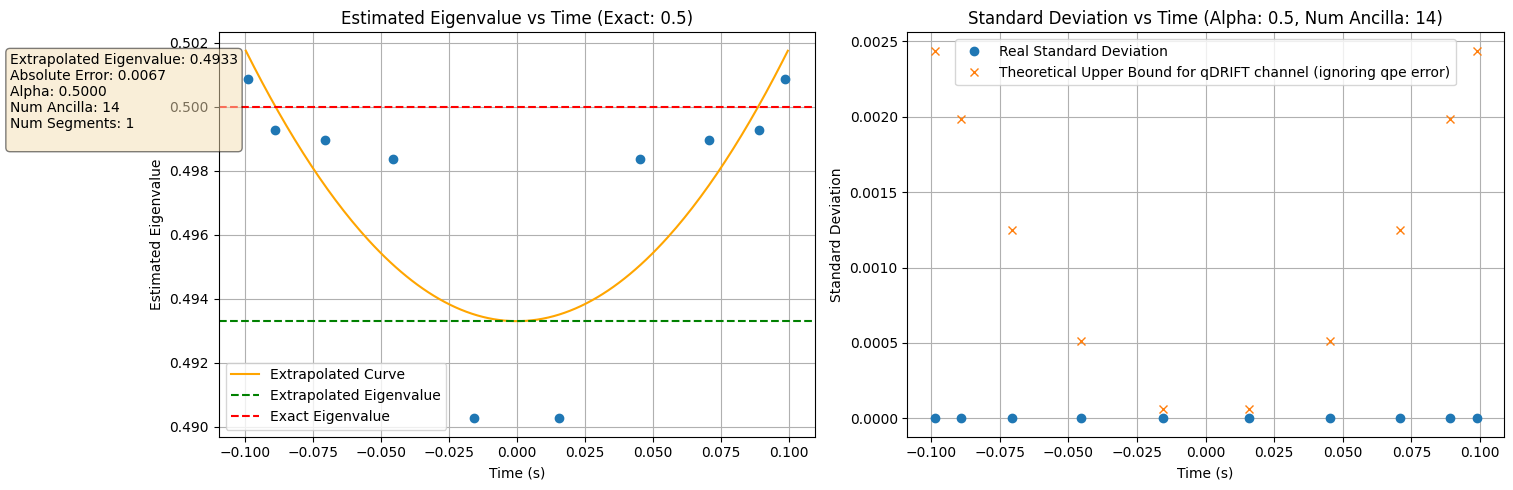

Group: ('H_many_diag_terms_3', np.float64(3.0666666666666664), np.int64(1))
Exact Eigenvalue: 3.0666666666666664
Alpha: 3.0666666666666664
Num Ancilla: 14
Polynomial Coefficients: [3.06517667e+00 8.14579250e-16 2.70667313e-01]
Y-intercept at x = 0: 3.0651766651523715
Correct eigenvalue: 3.0666666666666664
Error ratio: 0.0004858700590092075


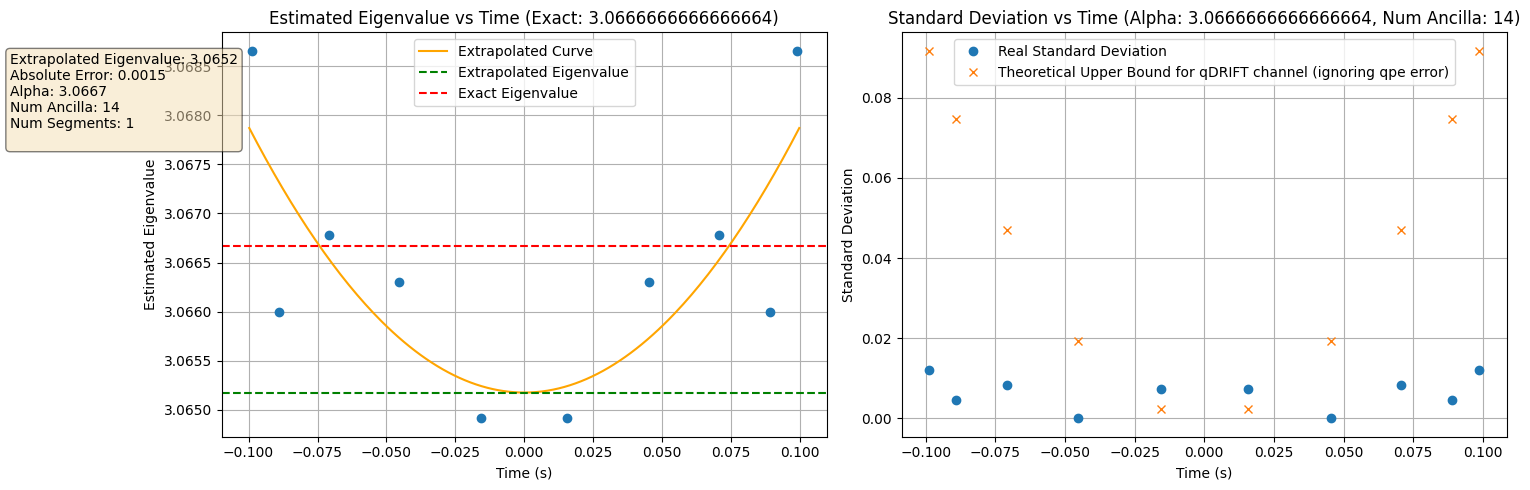

Group: ('H_many_diag_terms_3', np.float64(3.0666666666666664), np.int64(1024))
Exact Eigenvalue: 3.0666666666666664
Alpha: 3.0666666666666664
Num Ancilla: 14
Polynomial Coefficients: [3.06442586e+00 1.97995863e-15 2.89848979e-01]
Y-intercept at x = 0: 3.064425856274675
Correct eigenvalue: 3.0666666666666664
Error ratio: 0.0007306990408667317


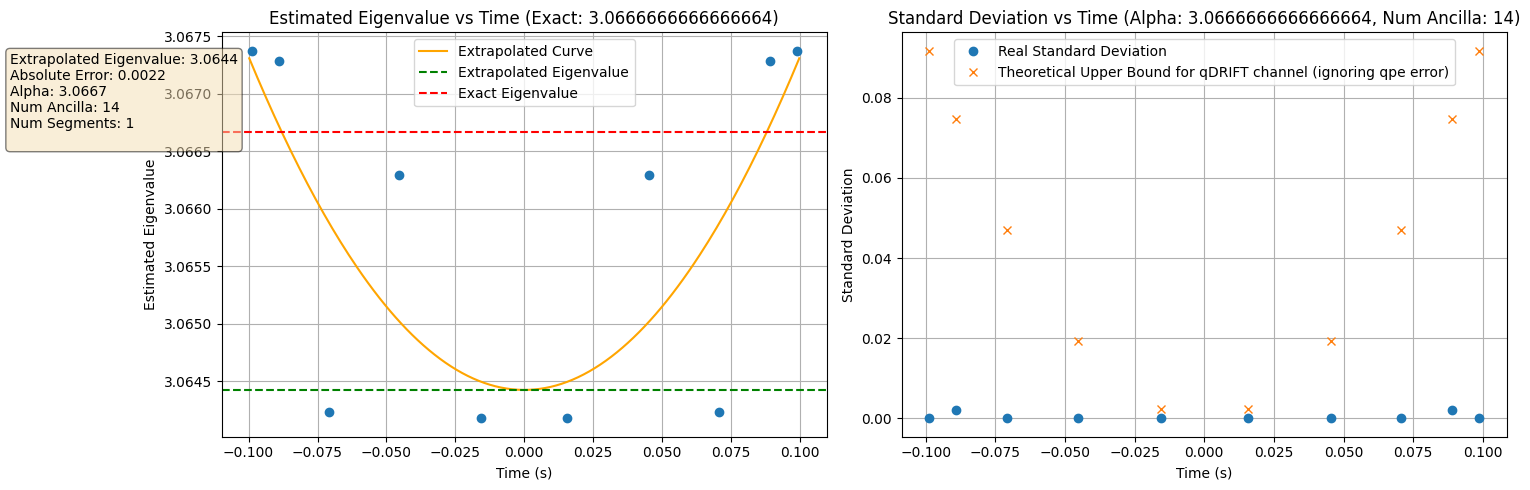

In [4]:
df = pd.read_csv("/Users/reyesfer/Desktop/qDriftExtraPolation/src/parameter_sweep/qdrift_qpe_fc_parameter_sweep_2025-09-04.csv")
plot_cheby_extrapolation(groupbys=["ham", "alpha", "n_shots"], df=df, show_stdevs=True)

Group: (6,)
Exact Eigenvalue: 0.8
Alpha: 1.0
Num Ancilla: 6
Polynomial Coefficients: [7.67032689e-01 3.11846454e-17 1.13815994e+00]
Y-intercept at x = 0: 0.7670326890627117
Correct eigenvalue: 0.8
Error ratio: 0.04120913867161041


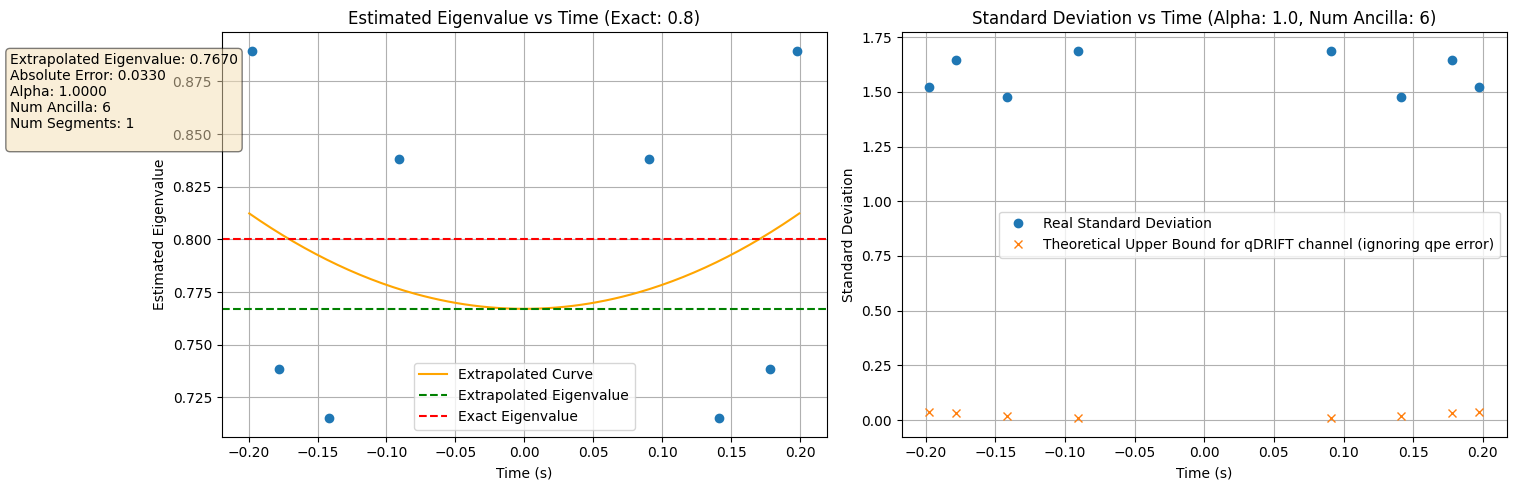

Group: (8,)
Exact Eigenvalue: 0.8
Alpha: 1.0
Num Ancilla: 8
Polynomial Coefficients: [8.00084761e-01 2.44154805e-16 6.69266856e-01]
Y-intercept at x = 0: 0.8000847611617157
Correct eigenvalue: 0.8
Error ratio: 0.00010595145214453705


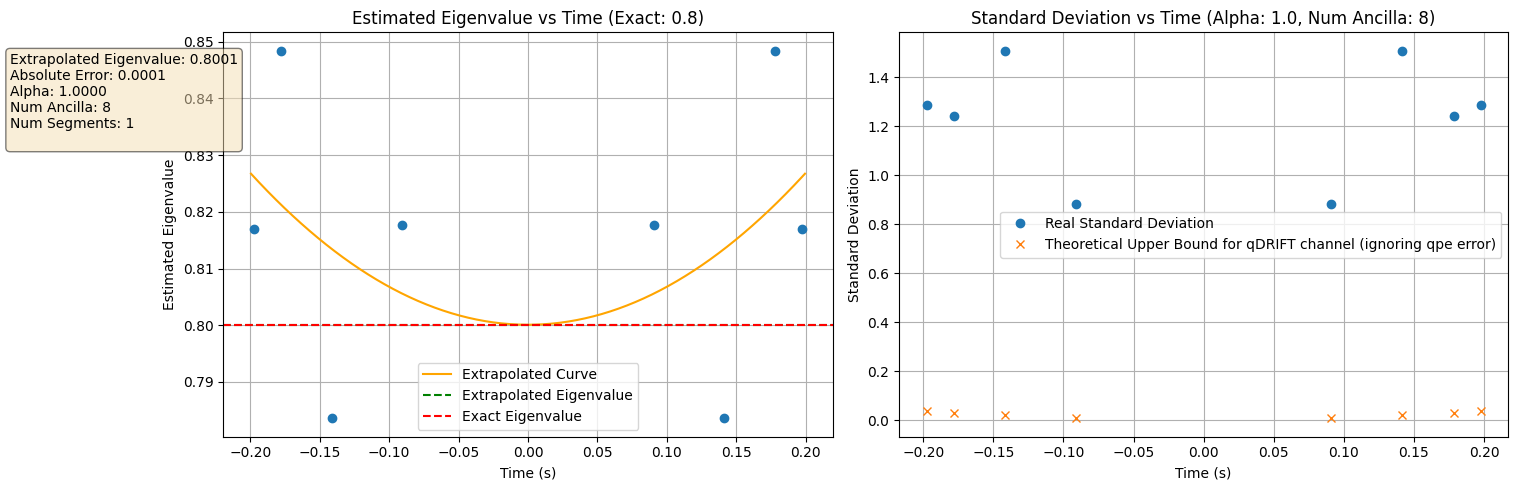

Group: (10,)
Exact Eigenvalue: 0.8
Alpha: 1.0
Num Ancilla: 10
Polynomial Coefficients: [7.20362274e-01 9.31770728e-17 2.43075062e+00]
Y-intercept at x = 0: 0.7203622743556555
Correct eigenvalue: 0.8
Error ratio: 0.09954715705543071


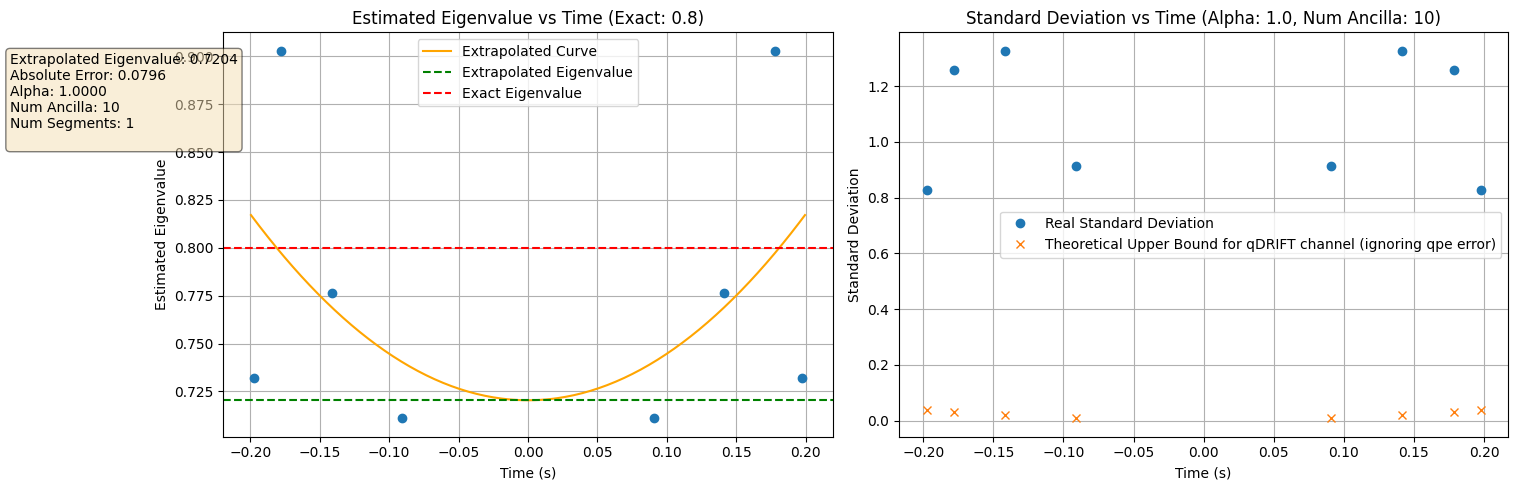

Group: (12,)
Exact Eigenvalue: 0.8
Alpha: 1.0
Num Ancilla: 12
Polynomial Coefficients: [ 8.77151167e-01  3.58565374e-16 -2.03252023e-01]
Y-intercept at x = 0: 0.8771511672848823
Correct eigenvalue: 0.8
Error ratio: 0.09643895910610281


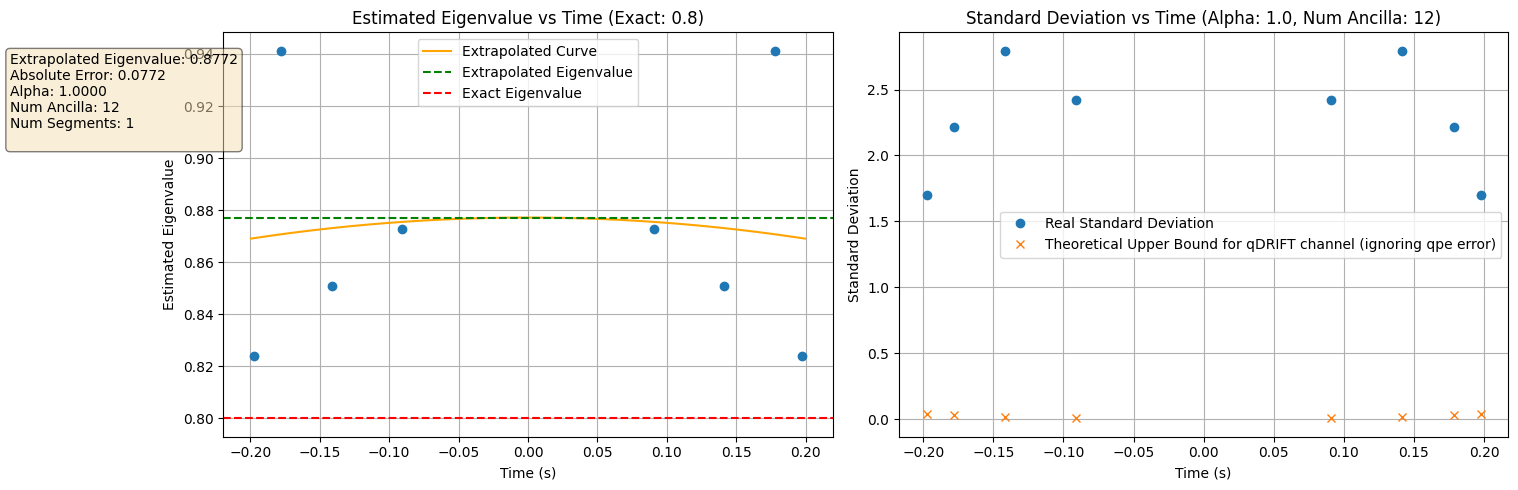

Group: (14,)
Exact Eigenvalue: 0.8
Alpha: 1.0
Num Ancilla: 14
Polynomial Coefficients: [ 8.49429898e-01  4.07568434e-16 -4.09110169e+00]
Y-intercept at x = 0: 0.8494298984368126
Correct eigenvalue: 0.8
Error ratio: 0.0617873730460157


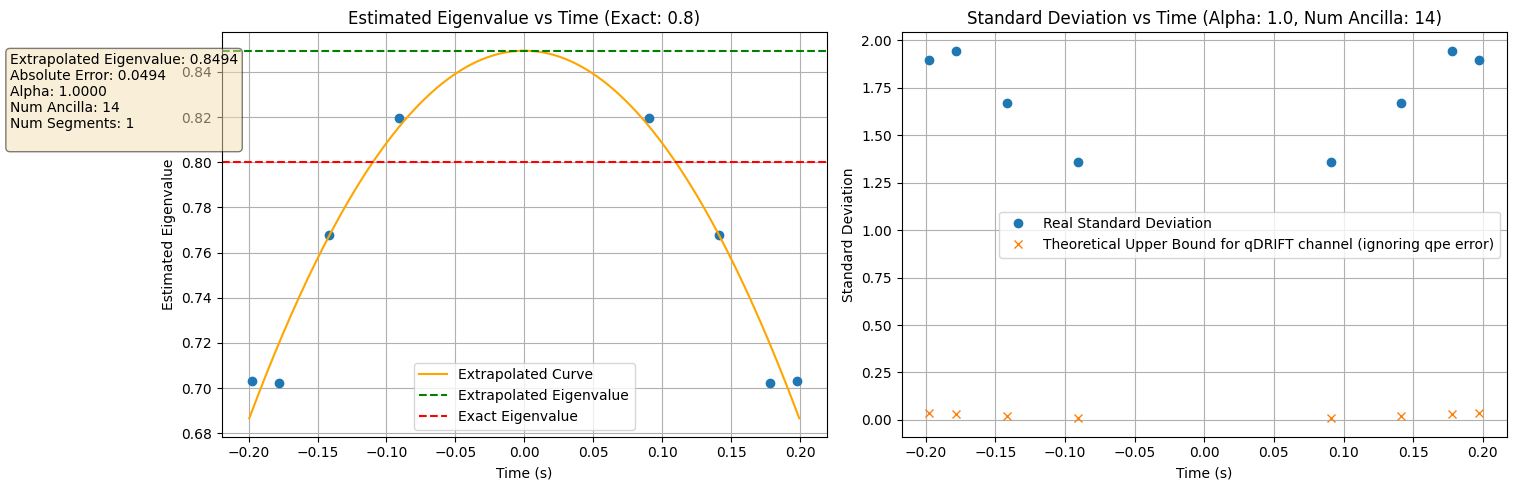

In [ ]:
df = pd.read_csv("/Users/reyesfer/Desktop/qDriftExtraPolation/src/parameter_sweep/qdrift_qpe_fc_parameter_sweep_2025-08-21.csv")
plot_cheby_extrapolation(["num_ancilla"], df, show_stdevs=True)

In [ ]:
# removethe row with the biggest time value
df_results_6_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_6_nodes_2025-07-17.csv")
df_results_6_nodes_just_positive = df_results_6_nodes_just_positive[df_results_6_nodes_just_positive["Time"] < max(df_results_6_nodes_just_positive["Time"])] 
plot_cheby_extrapolation(["num segments per invocation"], df_results_6_nodes_just_positive, show_stdevs=True)

NameError: name 'df_results_6_nodes_just_positive' is not defined

Group: (np.int64(1), np.int64(11), np.int64(1))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [ 1.10685062e+00 -3.49679343e-17  8.31285433e-02]
Y-intercept at x = 0: 1.1068506206493463
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.13569487362226493


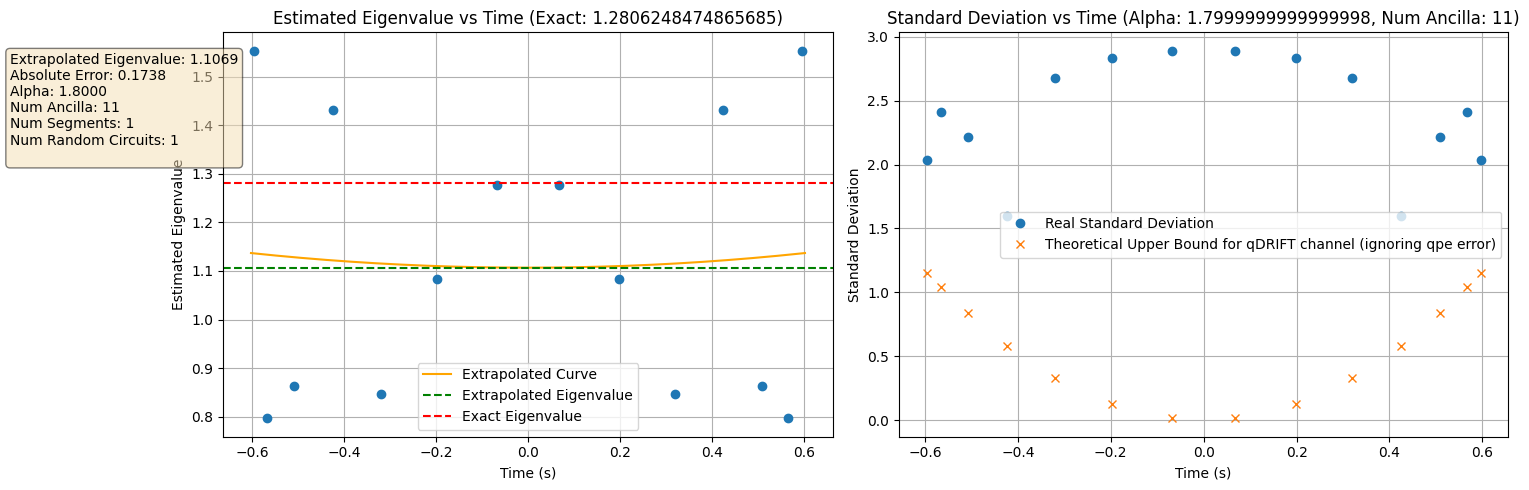

Group: (np.int64(1), np.int64(11), np.int64(2000))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.27898864e+00 1.04903803e-16 5.23829642e-01]
Y-intercept at x = 0: 1.2789886410672282
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.0012776625586732723


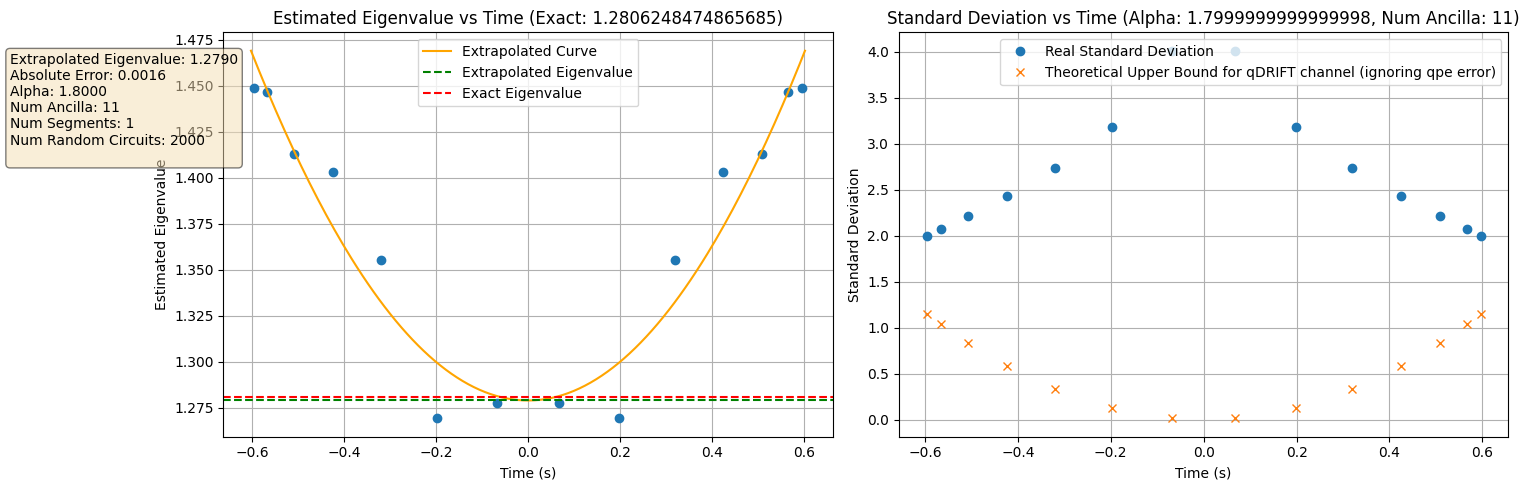

Group: (np.int64(1), np.int64(12), np.int64(1))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 12
Polynomial Coefficients: [1.21976969e+00 6.99358686e-17 2.82207678e-01]
Y-intercept at x = 0: 1.219769693478518
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.04751989165873863


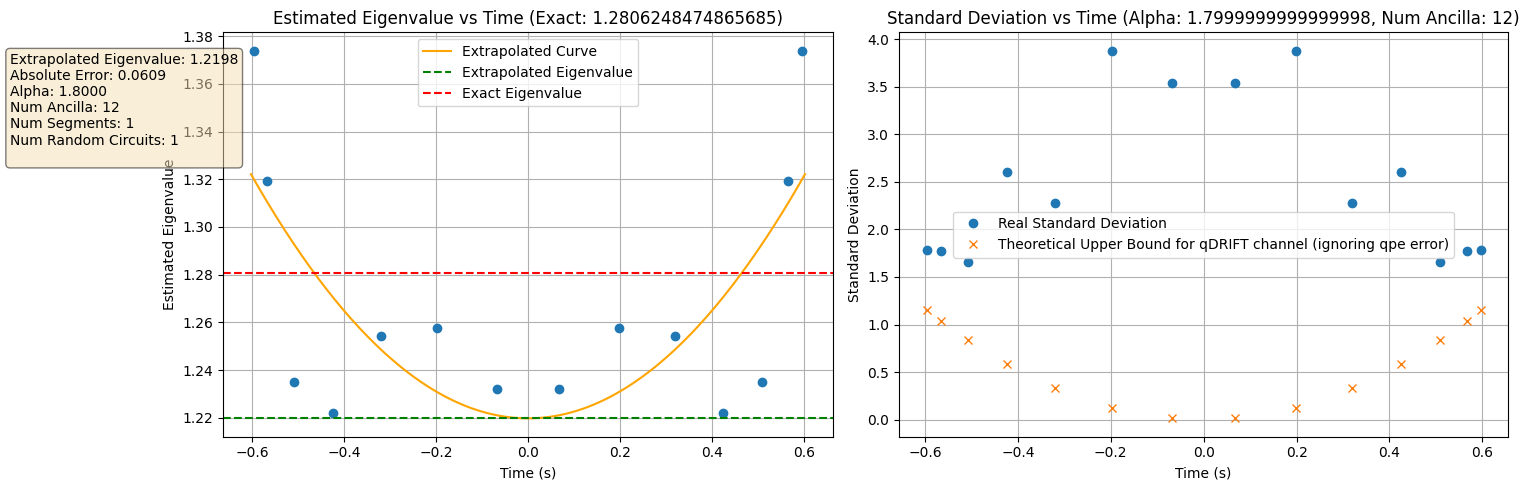

Group: (np.int64(1), np.int64(12), np.int64(2000))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 12
Polynomial Coefficients: [1.29233056e+00 6.99358686e-17 4.97016112e-01]
Y-intercept at x = 0: 1.2923305600802772
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.009140625856731673


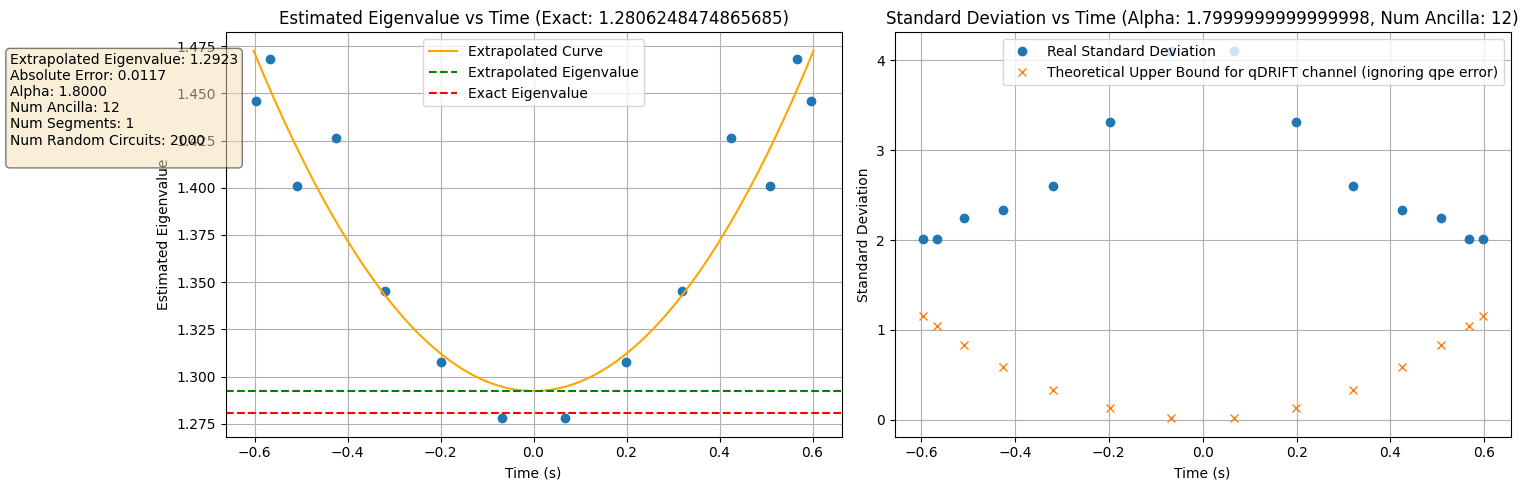

In [ ]:
df_6_nodes_many_crcs = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_6_nodes_2025-07-23.csv")
plot_cheby_extrapolation(["num segments per invocation", "Num Ancilla", "Num Random Circuits"], df_6_nodes_many_crcs, show_stdevs=True)

Group: (np.int64(1), np.int64(11), np.int64(1))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.28439160e+00 3.92509607e-16 1.55405184e+00]
Y-intercept at x = 0: 1.2843916020375357
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.0029413411416778766


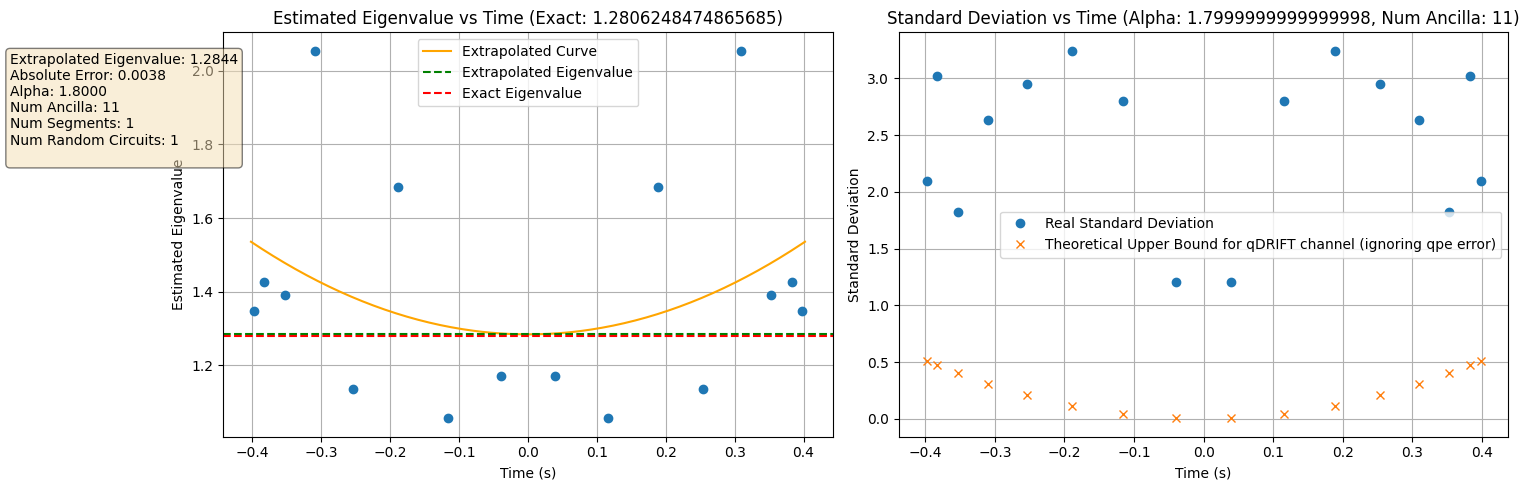

Group: (np.int64(1), np.int64(11), np.int64(1000))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.27574496e+00 2.69850355e-16 5.90020647e-01]
Y-intercept at x = 0: 1.2757449649784238
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.0038105480443567773


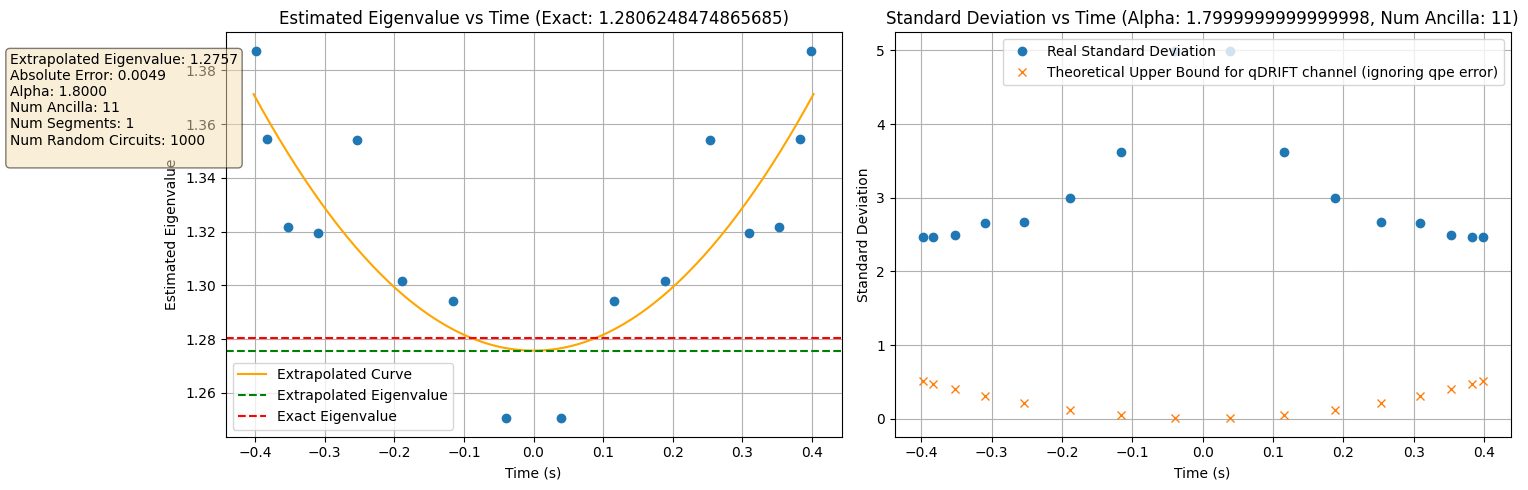

In [ ]:
df_8_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_8_nodes_2025-07-23.csv")
plot_cheby_extrapolation(["num segments per invocation", "Num Ancilla", "Num Random Circuits"], df_8_nodes_just_positive, show_stdevs=True)

In [ ]:
df_5_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_5_nodes_2025-07-10.csv")
df_5_nodes_just_positive

,Num Qubits,Time,Shots,Num Ancilla,Exact Eigenvalue,Expected Phase,Most Probable Bitstring,Estimated Phase,Estimated Eigenvalue,Eigenvalue Error,...,type of Hamiltonian,Num Random Circuits,Num Shots per Circuit,Circuit Depth,Raw results,estimnated energies counts,max energy,min energy,stdev energy,mean energy
0,2,0.574472,100,11,(1.2806248474865685+0j),0.117088,100001011,0.131836,1.441932,0.161307,...,Ising,100,1,2050,"{'00110100101': 1, '11100001111': 1, '00010000...","{np.float64(2.2483451332016036): 1, np.float64...",5.441957,-4.672926,2.023595,1.036375
1,2,0.716075,100,11,(1.2806248474865685+0j),0.145949,100100011,0.184082,1.615224,0.334599,...,Ising,100,1,2050,"{'00100100011': 2, '00110110111': 1, '01001001...","{np.float64(1.246764360010587): 2, np.float64(...",4.254423,-4.314405,1.591541,1.287381
2,2,0.790520,100,11,(1.2806248474865685+0j),0.161122,110100000,0.187500,1.490281,0.209657,...,Ising,100,1,2050,"{'00100010011': 1, '01001100010': 1, '00111011...","{np.float64(1.0672587785024836): 1, np.float64...",3.613156,-3.974084,1.591499,1.165136
3,2,0.790520,100,11,(2.561249694973137+0j),0.322244,1110111100,0.460205,3.657787,1.096537,...,Ising,100,1,2050,"{'01110011110': 2, '01110111011': 3, '01110111...","{np.float64(3.5937513777938177): 2, np.float64...",3.962441,-3.954679,2.592018,2.431798
4,2,0.379573,100,11,(2.561249694973137+0j),0.154727,1000011,0.190918,3.160325,0.599075,...,Ising,100,1,2050,"{'00100111100': 1, '01100100001': 1, '00101100...","{np.float64(2.5541244055956036): 1, np.float64...",7.840192,-8.195830,4.038020,2.060596
5,2,0.716075,100,11,(2.561249694973137+0j),0.291898,1110001010,0.382080,3.352554,0.791304,...,Ising,100,1,2050,"{'00011000111': 1, '10001100000': 1, '01011111...","{np.float64(0.8525983080484771): 1, np.float64...",4.357249,-4.271560,2.962349,1.813035
6,2,0.379573,100,11,(1.2806248474865685+0j),0.077364,11000110,0.075195,1.244732,0.035893,...,Ising,100,1,2050,"{'00001000011': 1, '11100010100': 1, '01101110...","{np.float64(0.5415390353636248): 1, np.float64...",7.128917,-8.220078,2.850282,0.888447
7,2,0.574472,100,11,(2.561249694973137+0j),0.234175,1010011000,0.320557,3.506030,0.944780,...,Ising,100,1,2050,"{'01010011000': 2, '01100110101': 1, '00011100...","{np.float64(3.546083535500867): 2, np.float64(...",5.441957,-5.415254,3.210538,2.034245
8,2,0.150455,100,11,(2.561249694973137+0j),0.061331,10001100,0.067139,2.803802,0.242552,...,Ising,100,1,2050,"{'00010110111': 1, '00010100111': 1, '00001110...","{np.float64(3.7316054106920156): 1, np.float64...",19.534852,-17.985115,5.730312,1.536076
9,2,0.150455,100,11,(1.2806248474865685+0j),0.030665,1000001,0.031250,1.305042,0.024417,...,Ising,100,1,2050,"{'11110101110': 1, '01111000000': 1, '11111101...","{np.float64(-1.6720854845723783): 1, np.float6...",19.636809,-13.295119,4.468328,1.941658


Group: ('(1.2806248474865685+0j)',)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.25648166e+00 1.22812895e-16 4.98528262e-01]
Y-intercept at x = 0: 1.2564816554726428
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.018852665604068636


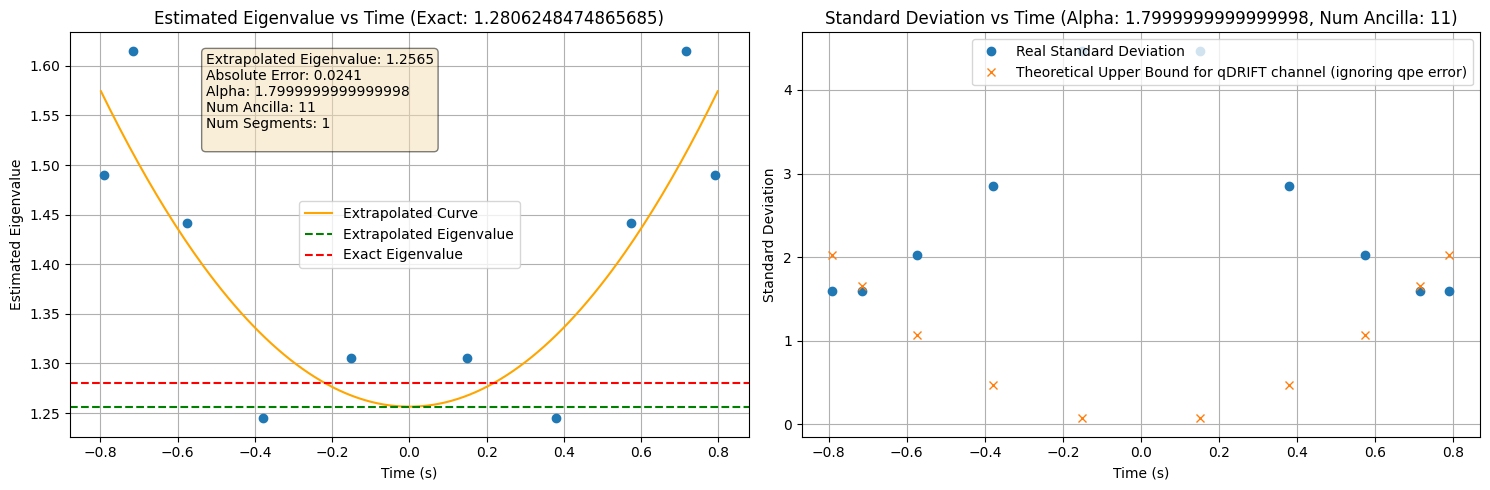

Group: ('(2.561249694973137+0j)',)
Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 11
Polynomial Coefficients: [ 2.91130923e+00 -4.91251580e-16  1.17714912e+00]
Y-intercept at x = 0: 2.9113092329367247
Correct eigenvalue: 2.561249694973137
Error ratio: 0.13667528732190218


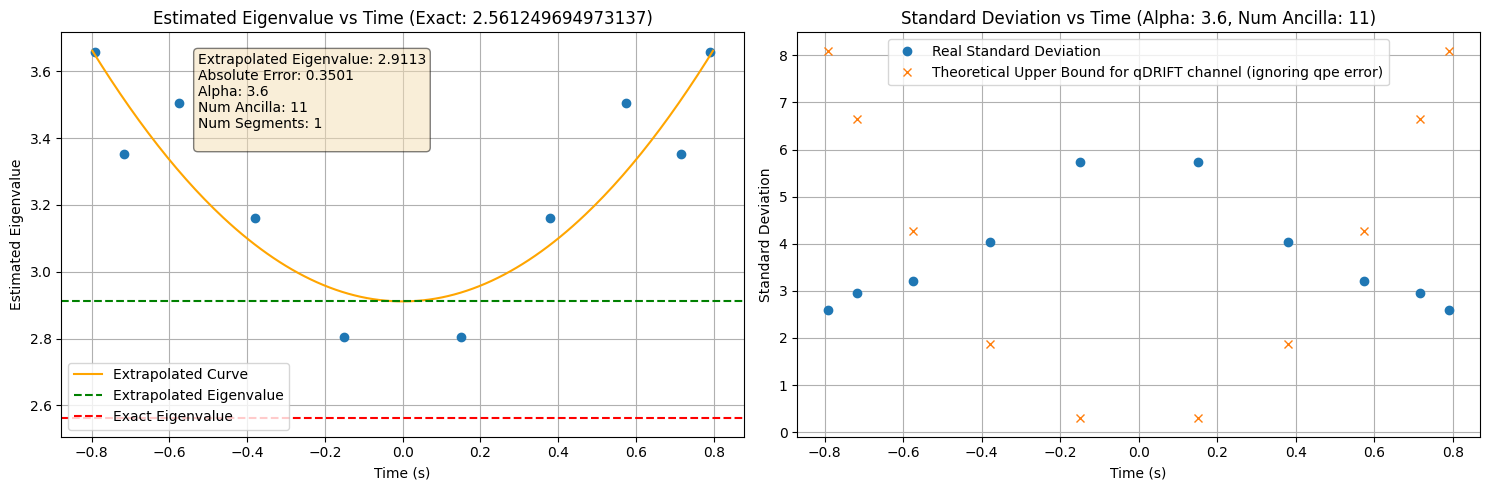

In [ ]:
plot_cheby_extrapolation(["Exact Eigenvalue"], df_5_nodes_just_positive, show_stdevs=True)

Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11


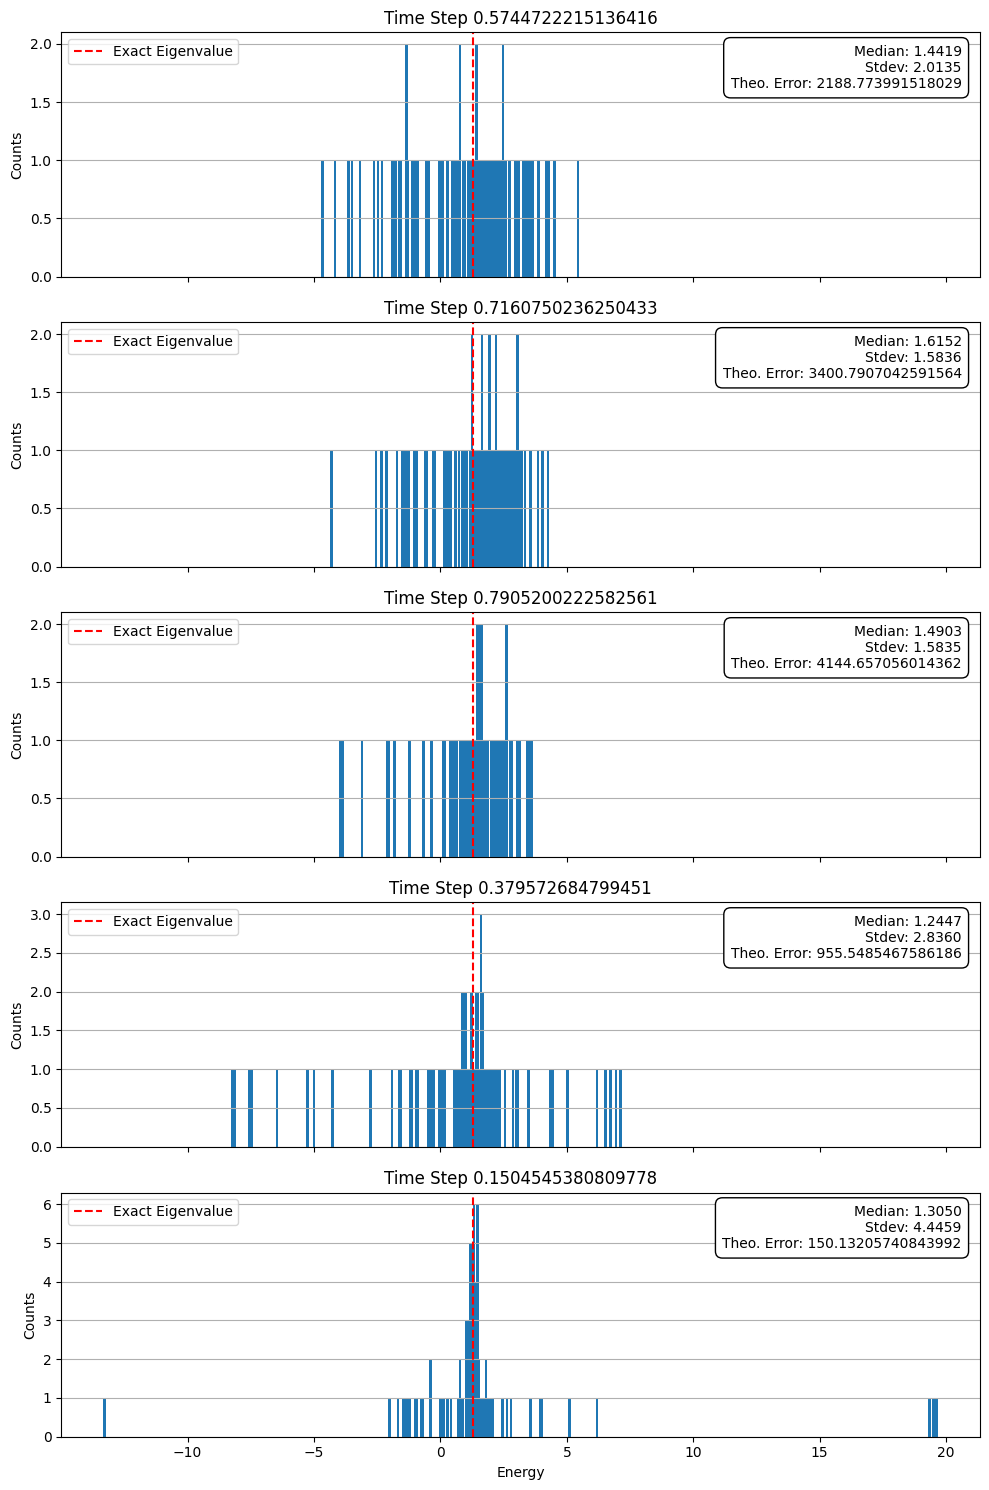

Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 11


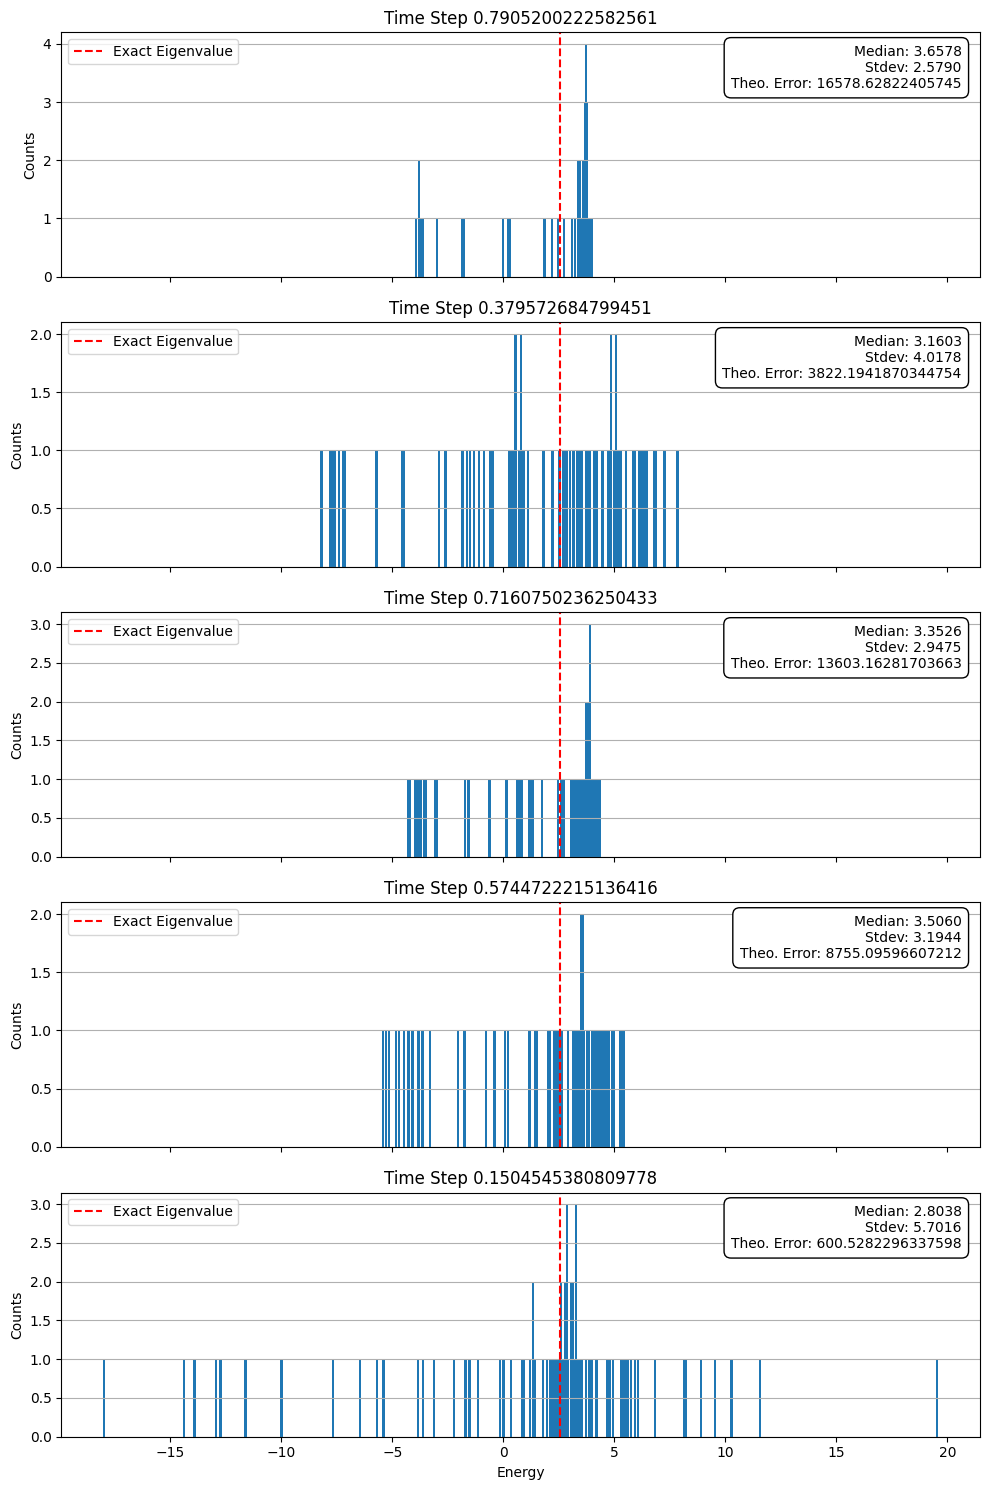

: 

In [ ]:

def plot_energy_histograms(group, exact_eigenvalue, theoretical_error, energy_counts_column="estimnated energies counts", time_column="Time"):
    """
    Plots histograms of estimated energy counts over time steps, with a text box showing
    median, standard deviation, and theoretical error.

    Parameters:
    - group: DataFrame containing energy counts and time values.
    - exact_eigenvalue: Float, value of the exact eigenvalue to mark.
    - theoretical_error: Float or list of floats for theoretical error(s) per time step.
    - energy_counts_column: Name of the column containing energy counts dictionaries.
    - time_column: Name of the column containing time step identifiers.
    """
    all_counts = group[energy_counts_column].values

    # Clean and parse
    c_cleaned = [x.replace("np.float64(", "").replace(")", "") for x in all_counts]
    counts = [ast.literal_eval(x) for x in c_cleaned]
    time_vals = group[time_column].values

    # Collect all possible energies
    all_estimated_energies = sorted(set(energy for count in counts for energy in count.keys()))

    num_times = len(counts)
    fig, axes = plt.subplots(num_times, 1, figsize=(10, 3 * num_times), sharex=True)

    if num_times == 1:
        axes = [axes]  # Ensure iterable

    # Handle theoretical_error as scalar or list
    if np.isscalar(theoretical_error):
        theoretical_error = [theoretical_error] * num_times

    for idx, (ax, count, time_val, theo_err) in enumerate(zip(axes, counts, time_vals, theoretical_error)):
        counts_for_energies = [count.get(energy, 0) for energy in all_estimated_energies]
        ax.bar(all_estimated_energies, counts_for_energies, width=0.1)
        ax.set_title(f"Time Step {time_val}")
        ax.set_ylabel("Counts")
        ax.grid(True, axis='y')
        ax.axvline(x=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
        ax.legend()

        # Weighted statistics
        energies = np.array(all_estimated_energies)
        counts_array = np.array(counts_for_energies)
        flatten_counts = np.repeat(energies, counts_array.astype(int))
        if counts_array.sum() > 0:
            median = np.median(flatten_counts)
            stdev = np.std(flatten_counts)
            
        else:
            median = np.nan
            stdev = np.nan

        # Add text box
        stats_text = (f"Median: {median:.4f}\n"
                      f"Stdev: {stdev:.4f}\n"
                      f"Theo. Error: {theo_err}")
        ax.text(0.98, 0.95, stats_text, ha='right', va='top', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    axes[-1].set_xlabel("Energy")

    plt.tight_layout()
    plt.show()

for group_name, group in df_5_nodes_just_positive.groupby("Exact Eigenvalue"):
    exact_eigenvalue = ast.literal_eval(group_name).real
    print(f"Exact Eigenvalue: {exact_eigenvalue}")
    alpha = group["Alpha"].iloc[0]
    print(f"Alpha: {alpha}")
    num_ancilla = group["Num Ancilla"].iloc[0]
    print(f"Num Ancilla: {num_ancilla}")

    stdevs = group["stdev energy"]
    stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2) * (2 ** (num_ancilla) - 1)

    plot_energy_histograms(group, exact_eigenvalue, stdev_theoretical_upper_bound)